## Reading Data and Cleaning Data

In [1]:
# Package use for data cleaning and visualization
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
warnings.filterwarnings('ignore')
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,BatchNormalization
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report
import tensorflow as tf
import matplotlib.pyplot as plt
# Readin 'train.csv' as a dataframe. Data comes from the link below
# https://www.kaggle.com/competitions/playground-series-s4e10/data?select=train.csv
df = pd.read_csv('train.csv')

In [2]:
df

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
58640,58640,34,120000,MORTGAGE,5.0,EDUCATION,D,25000,15.95,0.21,Y,10,0
58641,58641,28,28800,RENT,0.0,MEDICAL,C,10000,12.73,0.35,N,8,1
58642,58642,23,44000,RENT,7.0,EDUCATION,D,6800,16.00,0.15,N,2,1
58643,58643,22,30000,RENT,2.0,EDUCATION,A,5000,8.90,0.17,N,3,0


In [3]:
# Use info and describe methods to understand dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(6), object

In [4]:
# To get more statisticial information about this dataset
df.describe()

,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,58645.000000,58645.000000,5.864500e+04,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000
mean,29322.000000,27.550857,6.404617e+04,4.701015,9217.556518,10.677874,0.159238,5.813556,0.142382
std,16929.497605,6.033216,3.793111e+04,3.959784,5563.807384,3.034697,0.091692,4.029196,0.349445
min,0.000000,20.000000,4.200000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000
25%,14661.000000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000
50%,29322.000000,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000
75%,43983.000000,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000
max,58644.000000,123.000000,1.900000e+06,123.000000,35000.000000,23.220000,0.830000,30.000000,1.000000


In [5]:
# Check if there is any NULL value
df.isnull().sum()

id                            0
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64

In [6]:
#Checking number of unique values in each column
df.nunique()

id                            58645
person_age                       53
person_income                  2641
person_home_ownership             4
person_emp_length                36
loan_intent                       6
loan_grade                        7
loan_amnt                       545
loan_int_rate                   362
loan_percent_income              61
cb_person_default_on_file         2
cb_person_cred_hist_length       29
loan_status                       2
dtype: int64

In [7]:
# Federal child labor law generally prohibits the employment of minors in nonagricultural occupations under the age of 14
# Check if the applicants start work before 14 years old
df[df['person_age']-df['person_emp_length']<14]

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
699,699,30,76500,MORTGAGE,19.0,MEDICAL,A,14750,6.62,0.20,N,8,0
746,746,23,100000,MORTGAGE,17.0,PERSONAL,A,17000,7.49,0.17,N,3,0
3072,3072,24,72000,RENT,12.0,HOMEIMPROVEMENT,B,14000,12.69,0.19,N,2,0
8222,8222,26,64999,MORTGAGE,13.0,EDUCATION,B,12000,10.99,0.17,N,3,0
12638,12638,32,61000,MORTGAGE,21.0,VENTURE,B,12000,11.49,0.20,N,6,0
15921,15921,27,70000,RENT,14.0,VENTURE,E,9000,16.00,0.13,Y,7,0
16378,16378,36,54400,RENT,24.0,MEDICAL,A,6000,9.63,0.09,N,17,1
17542,17542,38,118000,MORTGAGE,27.0,VENTURE,B,25000,11.58,0.21,N,13,1
17861,17861,33,55400,MORTGAGE,21.0,MEDICAL,B,18000,11.11,0.33,N,7,1
18293,18293,23,36194,RENT,10.0,PERSONAL,B,9250,10.08,0.26,N,3,0


In [8]:
# We treat those data as incorrect, and drop them
df = df[df['person_age']-df['person_emp_length']>=14]
# We have 3 variables which are categorical (person_home_ownership, loan_intent, cb_person_default_on_file, loan_grade)
# loan_intent and cb_person_default_on_file are Nominal
df['person_home_ownership_code'] = le.fit_transform(df['person_home_ownership'])
df['loan_intent_id'] = le.fit_transform(df['loan_intent'])
df['cb_person_default_on_file'] = le.fit_transform(df['cb_person_default_on_file'])
# loan_grade is Ordinal
loan_grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5}
df['loan_grade']  = df['loan_grade'].map(loan_grade_map)
df['loan_grade'] = df['loan_grade'].fillna(0.0)
df = df[['id', 'person_age', 'person_income', 'person_home_ownership','person_home_ownership_code',
       'person_emp_length', 'loan_intent', 'loan_intent_id', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'loan_status']]
df

,id,person_age,person_income,person_home_ownership,person_home_ownership_code,person_emp_length,loan_intent,loan_intent_id,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,3,0.0,EDUCATION,1,2.0,6000,11.49,0.17,0,14,0
1,1,22,56000,OWN,2,6.0,MEDICAL,3,3.0,4000,13.35,0.07,0,2,0
2,2,29,28800,OWN,2,8.0,PERSONAL,4,1.0,6000,8.90,0.21,0,10,0
3,3,30,70000,RENT,3,14.0,VENTURE,5,2.0,12000,11.11,0.17,0,5,0
4,4,22,60000,RENT,3,2.0,MEDICAL,3,1.0,6000,6.92,0.10,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58640,58640,34,120000,MORTGAGE,0,5.0,EDUCATION,1,4.0,25000,15.95,0.21,1,10,0
58641,58641,28,28800,RENT,3,0.0,MEDICAL,3,3.0,10000,12.73,0.35,0,8,1
58642,58642,23,44000,RENT,3,7.0,EDUCATION,1,4.0,6800,16.00,0.15,0,2,1
58643,58643,22,30000,RENT,3,2.0,EDUCATION,1,1.0,5000,8.90,0.17,0,3,0


In [9]:
#To check data types of all the variables
df.dtypes

id                              int64
person_age                      int64
person_income                   int64
person_home_ownership          object
person_home_ownership_code      int32
person_emp_length             float64
loan_intent                    object
loan_intent_id                  int32
loan_grade                    float64
loan_amnt                       int64
loan_int_rate                 float64
loan_percent_income           float64
cb_person_default_on_file       int32
cb_person_cred_hist_length      int64
loan_status                     int64
dtype: object

<Axes: ylabel='cb_person_cred_hist_length'>

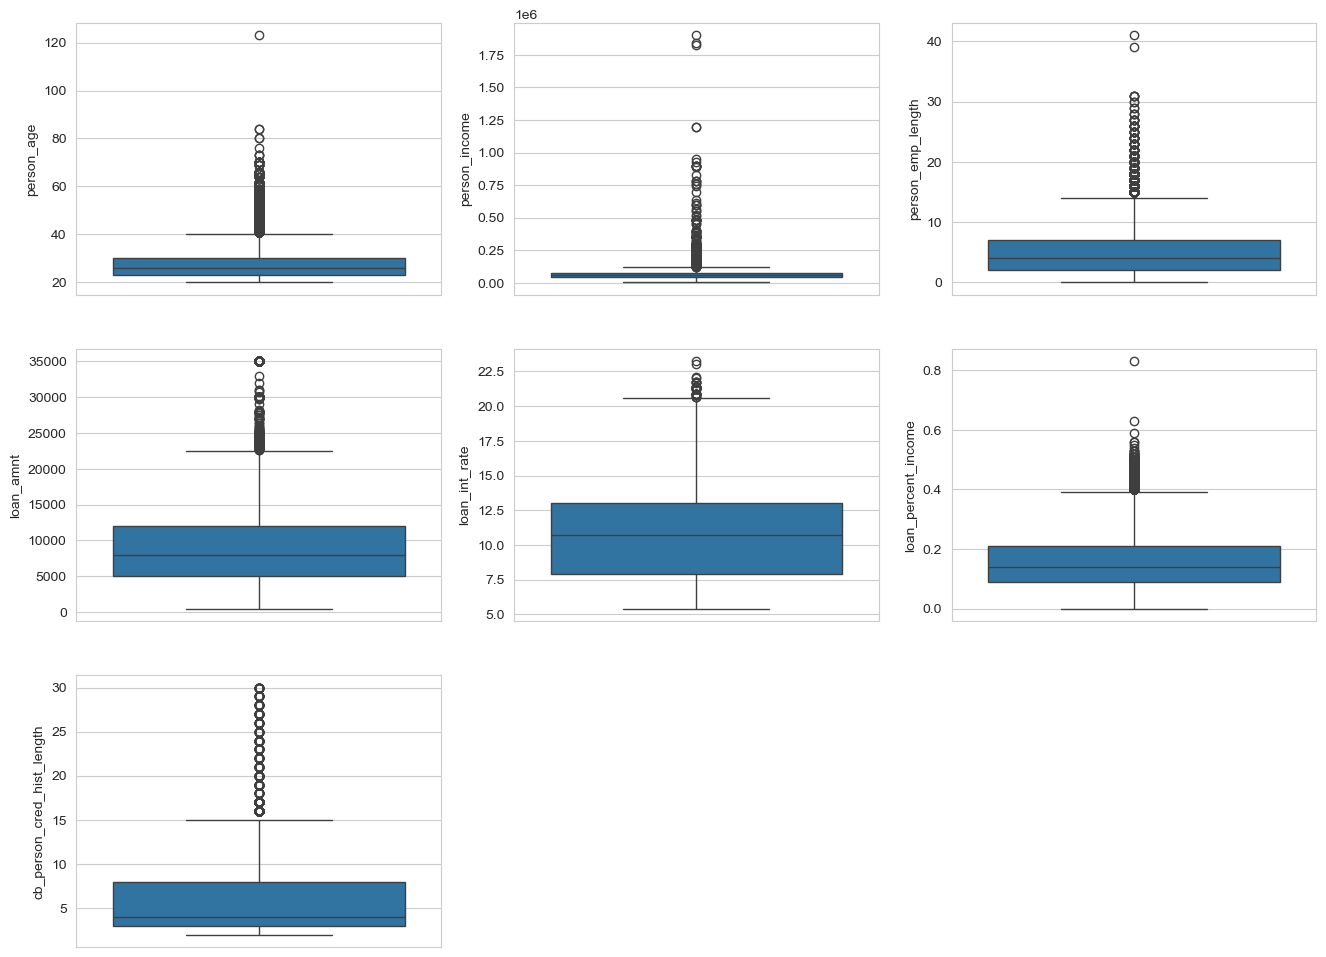

In [10]:
# Use boxplot to check if there is any outliers
plt.figure(figsize=(16,12))
sns.set_style(style='whitegrid')
plt.subplot(3,3,1)
sns.boxplot(y='person_age',data=df)
plt.subplot(3,3,2)
sns.boxplot(y='person_income',data=df)
plt.subplot(3,3,3)
sns.boxplot(y='person_emp_length',data=df)
plt.subplot(3,3,4)
sns.boxplot(y='loan_amnt',data=df)
plt.subplot(3,3,5)
sns.boxplot(y='loan_int_rate',data=df)
plt.subplot(3,3,6)
sns.boxplot(y='loan_percent_income',data=df)
plt.subplot(3,3,7)
sns.boxplot(y='cb_person_cred_hist_length',data=df)

In [11]:
# We drop the data with applicant age greater then 100
df = df[df['person_age']<100]

## Data Visualization

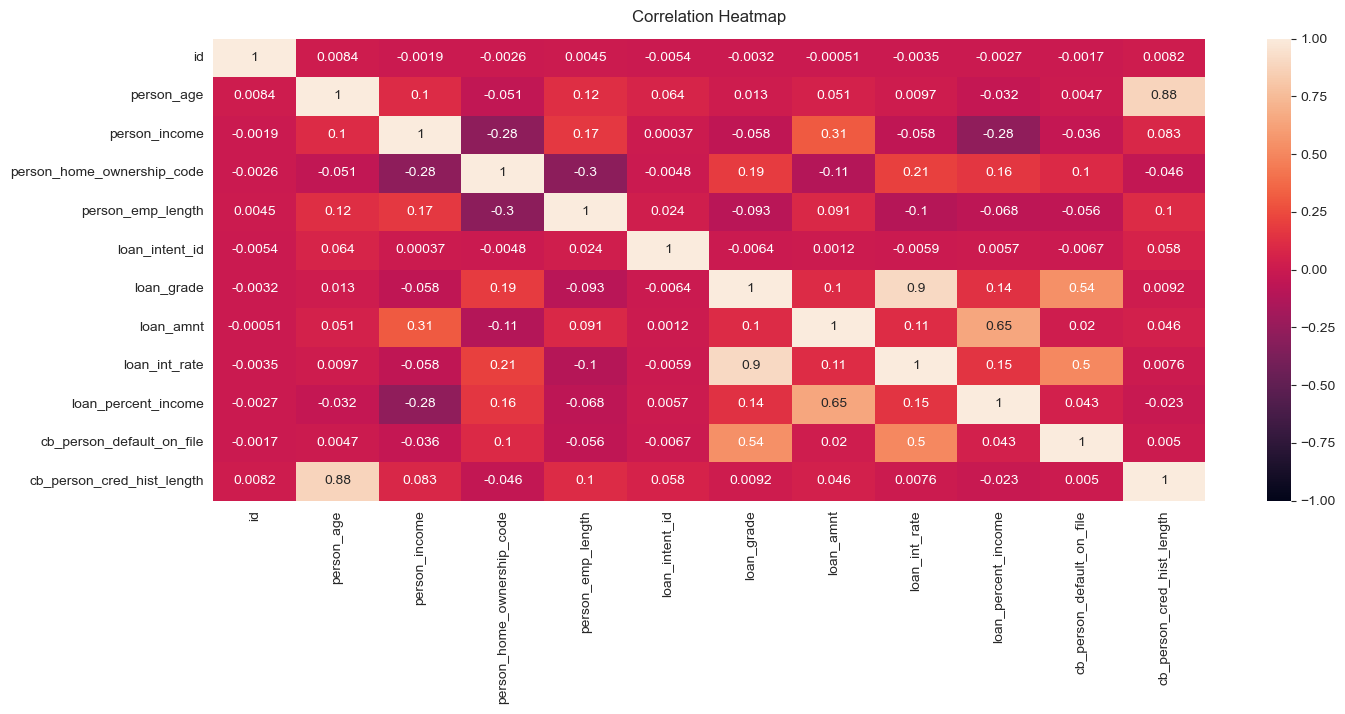

In [12]:
# Create a heatmap of the correlations between correlations of the train data
plt.figure(figsize=(16, 6))
heatmap = sns.heatmap(df.drop(['person_home_ownership','loan_intent','loan_status'], axis=1).corr(), vmin=-1, vmax=1, annot=True)
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':12}, pad=12);

In [13]:
# Drop the column of loan_int_rate as the correlation to loan_grade is too high
df = df.drop('loan_int_rate', axis=1)

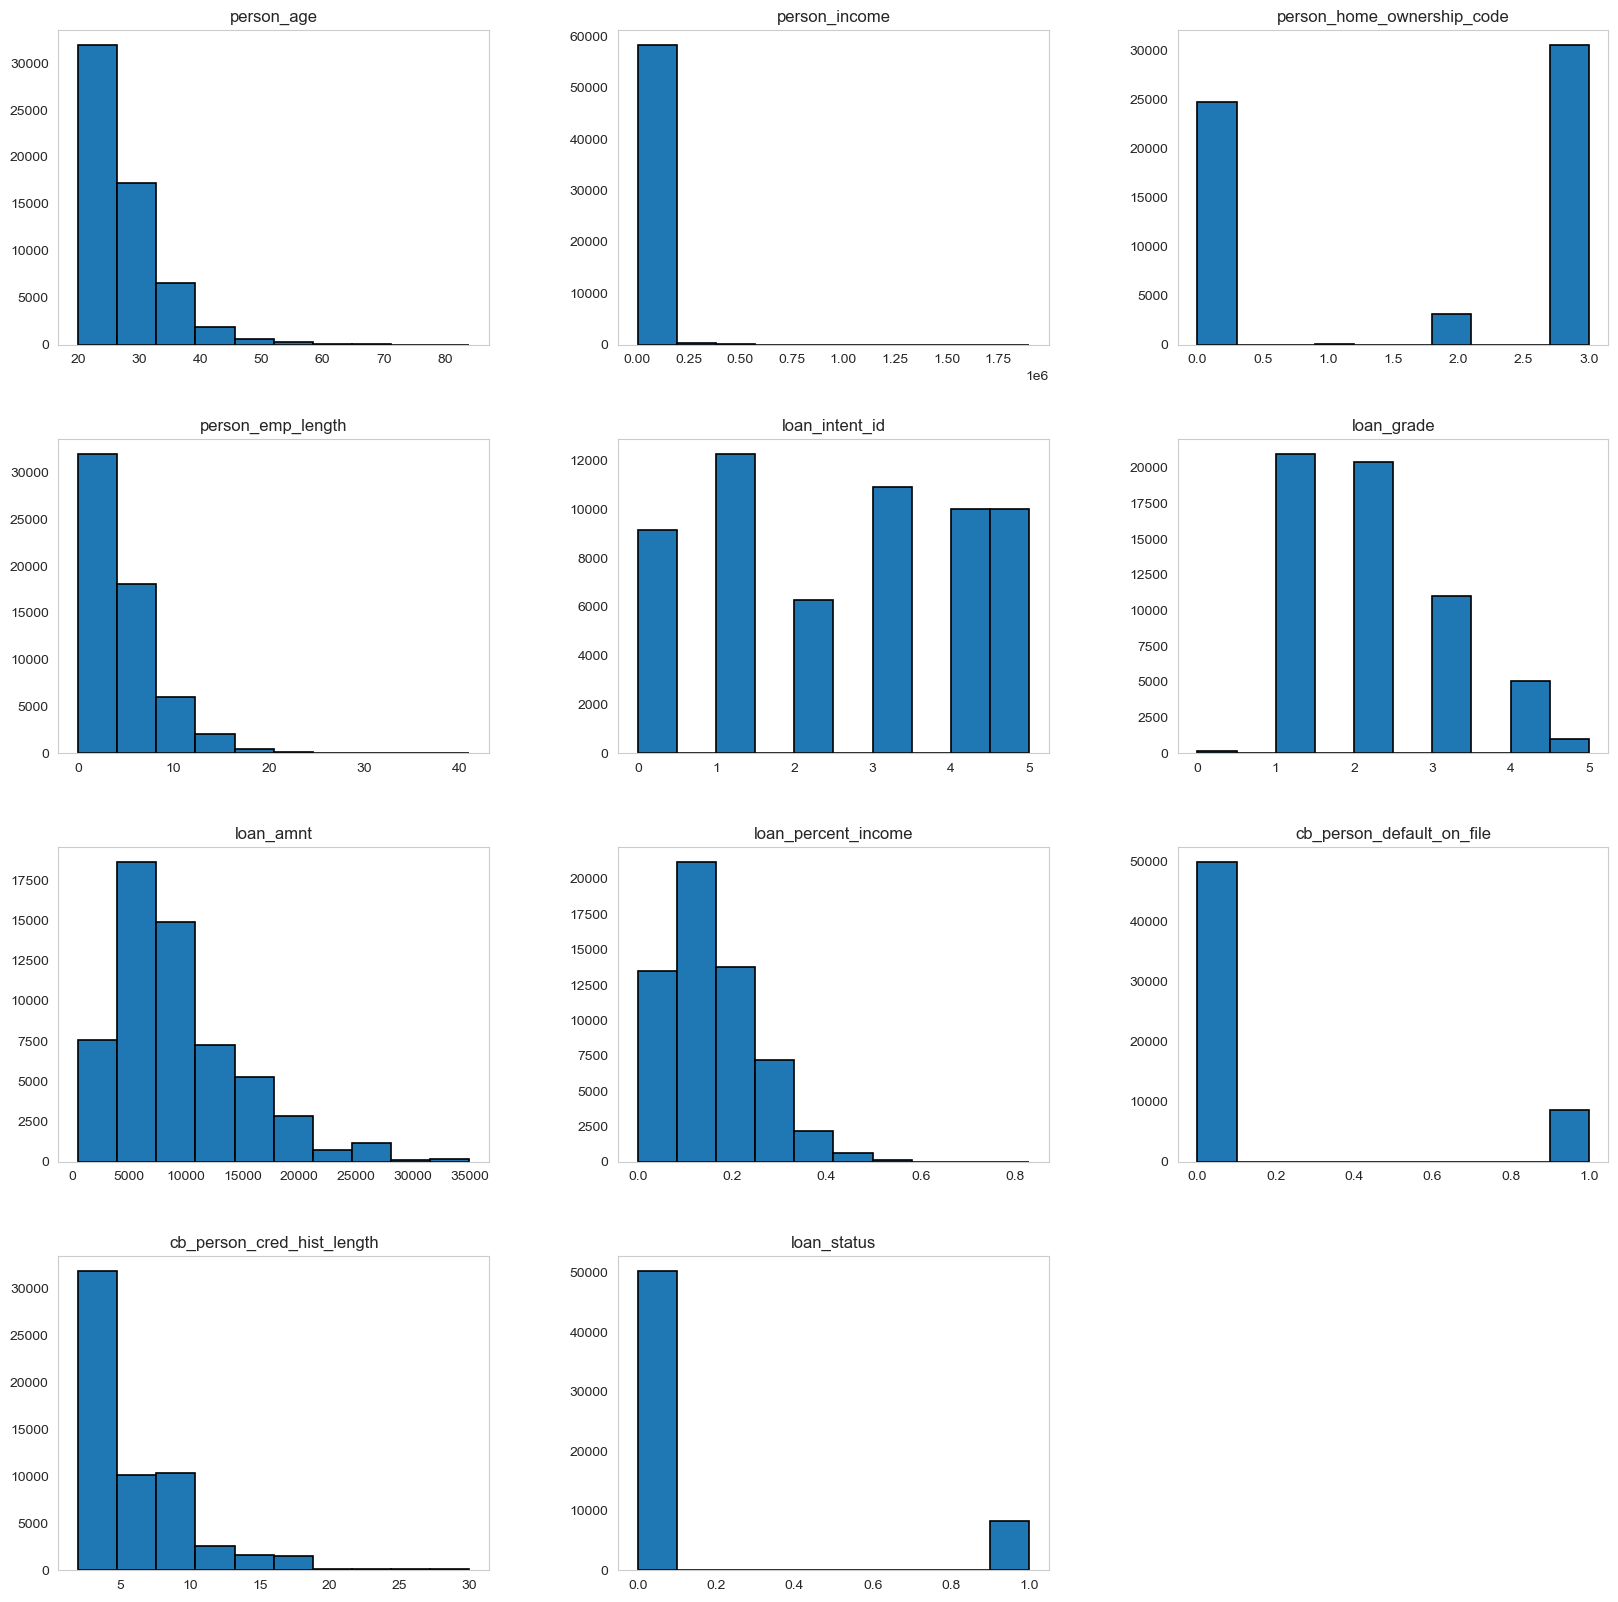

In [14]:
# Create a Histogram for each column in the train data
df.drop('id', axis=1).hist(edgecolor='black', linewidth=1.2, figsize=(20, 20),grid=False)
plt.show()

##  Models

In [15]:
# Split the data into training and testing set
from sklearn.model_selection import train_test_split
X = df.drop(['person_home_ownership', 'loan_intent', 'loan_percent_income', 'loan_status','id'], axis=1)
y = df['loan_status']

As the value ranges of some of the features such as person_income and loan_amnt are much larger then others, we divide them by 1000 to aviod give more importance to a feature based on its value range.

In [16]:
'''from sklearn.preprocessing import StandardScaler
X_train_scaled = StandardScaler().fit_transform(X_train)

X_test_scaled = StandardScaler().fit_transform(X_test)'''

'from sklearn.preprocessing import StandardScaler\nX_train_scaled = StandardScaler().fit_transform(X_train)\n\nX_test_scaled = StandardScaler().fit_transform(X_test)'

In [17]:
X['person_income'] = X['person_income']/1000
X['loan_amnt'] = X['loan_amnt']/1000
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=16)

### Logisitic Regression

In [18]:
from sklearn.metrics import recall_score, precision_score, accuracy_score,f1_score
from sklearn.linear_model import LogisticRegression
import time
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 58616 entries, 0 to 58644
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  58616 non-null  int64  
 1   person_income               58616 non-null  float64
 2   person_home_ownership_code  58616 non-null  int32  
 3   person_emp_length           58616 non-null  float64
 4   loan_intent_id              58616 non-null  int32  
 5   loan_grade                  58616 non-null  float64
 6   loan_amnt                   58616 non-null  float64
 7   cb_person_default_on_file   58616 non-null  int32  
 8   cb_person_cred_hist_length  58616 non-null  int64  
dtypes: float64(4), int32(3), int64(2)
memory usage: 3.8 MB


In [19]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression

In [20]:
start_time = time.time()
lrc = LogisticRegression(max_iter=750, solver='lbfgs',random_state=374)
lrc.fit(X_train, y_train)
y_pred = lrc.predict(X_test)
time_LR = time.time()-start_time
print("--- %s seconds ---" % time_LR)

score_LR = lrc.score(X_train, y_train)
print('Accuracy train data: %.2f%%' % (score_LR * 100))
accuracy_LR = accuracy_score(y_test, y_pred)
precision_LR = precision_score(y_test, y_pred)
recall_LR = recall_score(y_test, y_pred)
fscore_LR = f1_score(y_test, y_pred)
print('Accuracy predict: %.2f%%' % (accuracy_LR * 100.0))
print('Precision: %.2f%%' % (precision_LR * 100.0))
print('Recall: %.2f%%' % (recall_LR * 100.0))
print('F1_score: %.2f%%' % (fscore_LR * 100.0))

--- 0.19669103622436523 seconds ---
Accuracy train data: 89.12%
Accuracy predict: 89.45%
Precision: 74.34%
Recall: 38.53%
F1_score: 50.76%


In [21]:
coefficients = lrc.coef_[0]  # Assuming a single target variable
odds_ratios = np.exp(coefficients)

print("Odds Ratios:", odds_ratios)

Odds Ratios: [1.01694038 0.95153647 1.41453093 0.97618096 0.89450334 2.58562359
 1.19300102 0.93846381 0.99266817]


In [22]:
import statsmodels.api as sm

# Add intercept to the training data
X_train_with_intercept = sm.add_constant(X_train)

# Fit the model with statsmodels for standard errors
logit_model = sm.Logit(y_train, X_train_with_intercept).fit()

# Print the summary of the logistic regression
print(logit_model.summary())

# Extract coefficients, p-values, confidence intervals, and odds ratios
params = logit_model.params  # Coefficients
pvalues = logit_model.pvalues  # P-values
conf = logit_model.conf_int()  # Confidence intervals
conf.columns = ['2.5%', '97.5%']
odds_ratios = np.exp(params)  # Odds Ratios

# Combine everything into a single DataFrame
results_LR = conf
results_LR["Odds Ratio"] = odds_ratios
results_LR["p-value"] = pvalues

Optimization terminated successfully.
         Current function value: 0.282069
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:            loan_status   No. Observations:                41031
Model:                          Logit   Df Residuals:                    41021
Method:                           MLE   Df Model:                            9
Date:                Thu, 12 Dec 2024   Pseudo R-squ.:                  0.3123
Time:                        16:29:07   Log-Likelihood:                -11574.
converged:                       True   LL-Null:                       -16828.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -3.8792      0.138    -28.072      0.000      

In [23]:
results_LR

,2.5%,97.5%,Odds Ratio,p-value
const,-4.150040,-3.608357,0.020667,2.146835e-173
person_age,0.005536,0.027875,1.016846,3.374501e-03
person_income,-0.051829,-0.047524,0.951537,0.000000e+00
person_home_ownership_code,0.316792,0.375556,1.413649,5.563216e-118
person_emp_length,-0.034155,-0.014194,0.976115,2.061764e-06
loan_intent_id,-0.131039,-0.092154,0.894405,2.323446e-29
loan_grade,0.913211,0.987192,2.586230,0.000000e+00
loan_amnt,0.169378,0.183460,1.192938,0.000000e+00
cb_person_default_on_file,-0.149786,0.022781,0.938472,1.491674e-01
cb_person_cred_hist_length,-0.024164,0.009675,0.992782,4.013363e-01


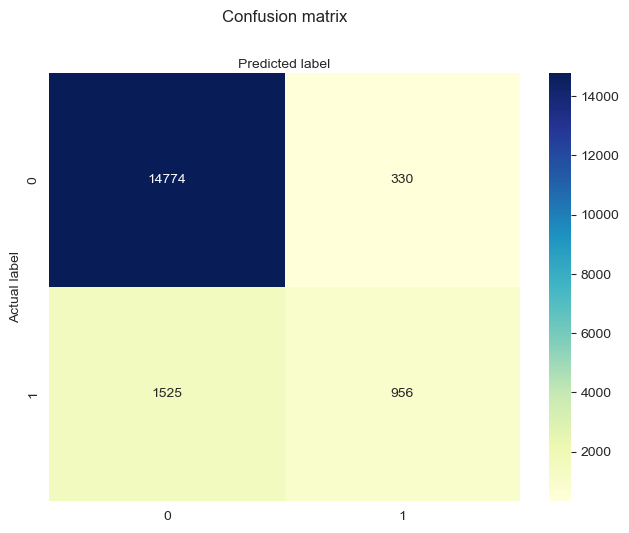

In [24]:
from sklearn import metrics

cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

class_names = [0, 1]  
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)


sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
 

plt.show()

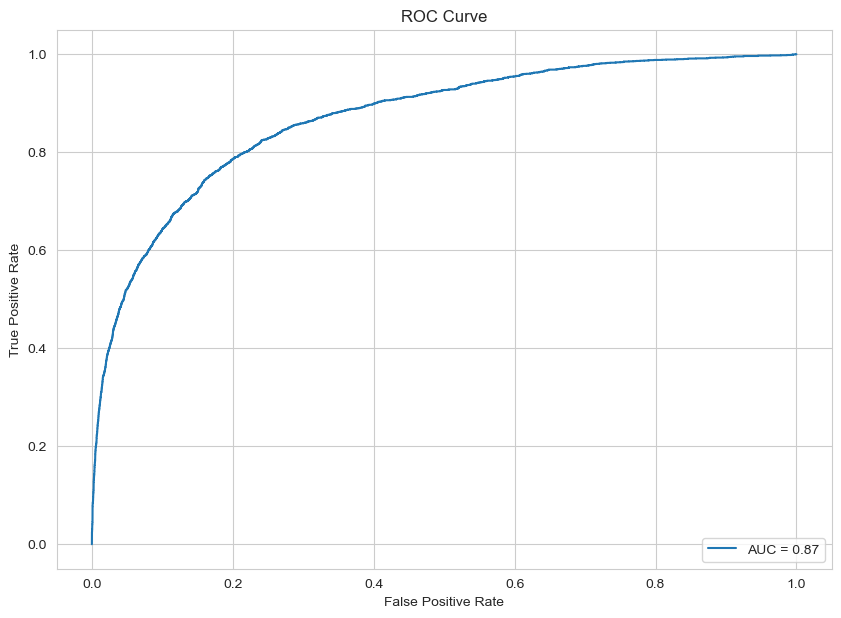

In [25]:
from sklearn.metrics import roc_curve, auc
y_pred_proba = lrc.predict_proba(X_test)[:,1]  
fpr_LR, tpr_LR, _ = metrics.roc_curve(y_test, y_pred_proba)
auc_LR = metrics.roc_auc_score(y_test, y_pred_proba)


plt.figure(figsize=(10,7))
plt.plot(fpr_LR, tpr_LR, label="AUC = {:.2f}".format(auc_LR))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc=4)
plt.grid(True)
plt.show()

In [26]:
%%time

cv_scores = cross_val_score(lrc, X, y, cv=5)
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Average CV Score: {cv_scores.mean()}")

Cross-Validation Scores: [0.89039577 0.889704   0.89354261 0.8932014  0.893372  ]
Average CV Score: 0.8920431562608655
CPU times: total: 1.56 s
Wall time: 1.15 s


### Decision Tree

In [27]:
from sklearn.tree import DecisionTreeClassifier
X_train_split, X_val, y_train_split, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Dynamically determine the number of features
n_features = X_train_split.shape[1]
# Define valid ranges for hyperparameters
max_features_range = range(1, n_features + 1)  # Adjusted based on number of features
max_depth_range = [1, 2, 3, 4, 5, 6, 7, 8]
min_samples_leaf_range = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20]

# Initialize variables to track the best combination and accuracy
best_accuracy = 0
best_params = (None, None, None)

# Grid search over hyperparameters
for max_features in max_features_range:
    for max_depth in max_depth_range:
        for min_samples_leaf in min_samples_leaf_range:
            
            # Create and train a DecisionTreeClassifier
            dt_classifier = DecisionTreeClassifier(max_features=max_features, 
                                                   max_depth=max_depth, 
                                                   min_samples_leaf=min_samples_leaf)
            dt_classifier.fit(X_train_split, y_train_split)
            
            # Predict and calculate validation accuracy
            y_val_pred = dt_classifier.predict(X_val)
            val_accuracy = accuracy_score(y_val, y_val_pred)
            
            # Update best parameters if accuracy improves
            if val_accuracy > best_accuracy:
                best_accuracy = val_accuracy
                best_params = (max_features, max_depth, min_samples_leaf)

# Display the best parameter combination and the associated accuracy
print(f"Best Parameters: max_features={best_params[0]}, max_depth={best_params[1]}, min_samples_leaf={best_params[2]}")
print(f"Best Validation Accuracy: {best_accuracy:.2f}")

Best Parameters: max_features=8, max_depth=8, min_samples_leaf=5
Best Validation Accuracy: 0.94


In [28]:
start_time = time.time()
tree_clf = DecisionTreeClassifier(max_features=8, max_depth=8, min_samples_leaf=5)
tree_clf.fit(X_train, y_train)
y_pred = tree_clf.predict(X_test)
time_DT = time.time()-start_time
print("--- %s seconds ---" % time_DT)

score_DT = tree_clf.score(X_train, y_train)
print('Accuracy train data: %.2f%%' % (score_DT * 100))
accuracy_DT = accuracy_score(y_test, y_pred)
precision_DT = precision_score(y_test, y_pred)
recall_DT = recall_score(y_test, y_pred)
fscore_DT = f1_score(y_test, y_pred)
print('Accuracy predict: %.2f%%' % (accuracy_DT * 100.0))
print('Precision: %.2f%%' % (precision_DT * 100.0))
print('Recall: %.2f%%' % (recall_DT * 100.0))
print('F1_score: %.2f%%' % (fscore_DT * 100.0))
min_impurity = tree_clf.tree_.impurity[0]
print(f"Root Node Gini Impurity: {min_impurity}")  

--- 0.0465395450592041 seconds ---
Accuracy train data: 94.46%
Accuracy predict: 94.27%
Precision: 87.48%
Recall: 69.29%
F1_score: 77.33%
Root Node Gini Impurity: 0.2449128804857389


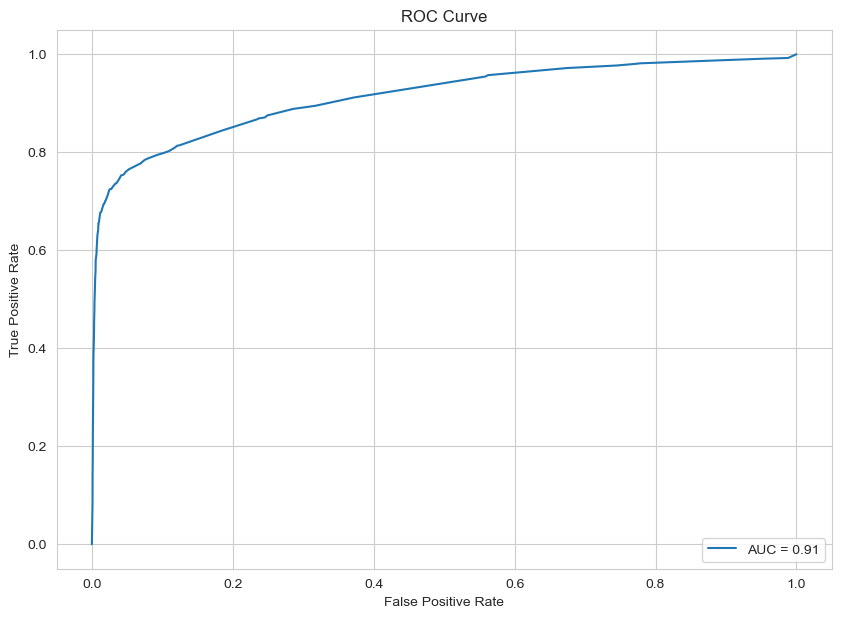

In [29]:
# Compute the ROC curve
y_pred_proba = tree_clf.predict_proba(X_test)[:,1]  
fpr_DT, tpr_DT, _ = metrics.roc_curve(y_test, y_pred_proba)
auc_DT = metrics.roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(10,7))
plt.plot(fpr_DT, tpr_DT, label="AUC = {:.2f}".format(auc_DT))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc=4)
plt.grid(True)
plt.show()

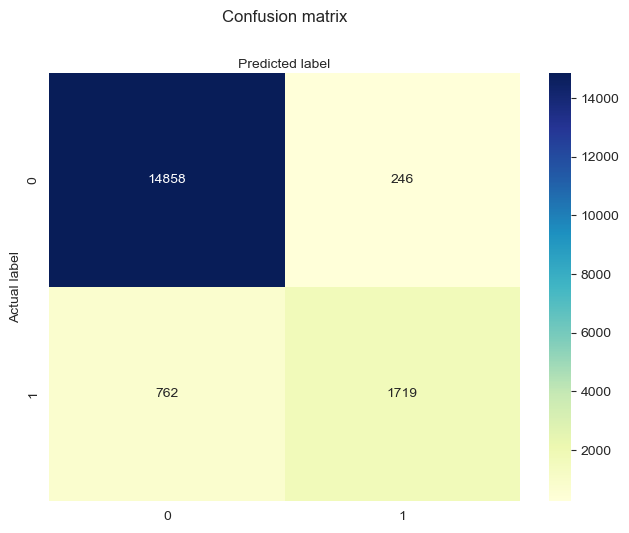

In [30]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

class_names = [0, 1]  
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)


sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
 

plt.show()

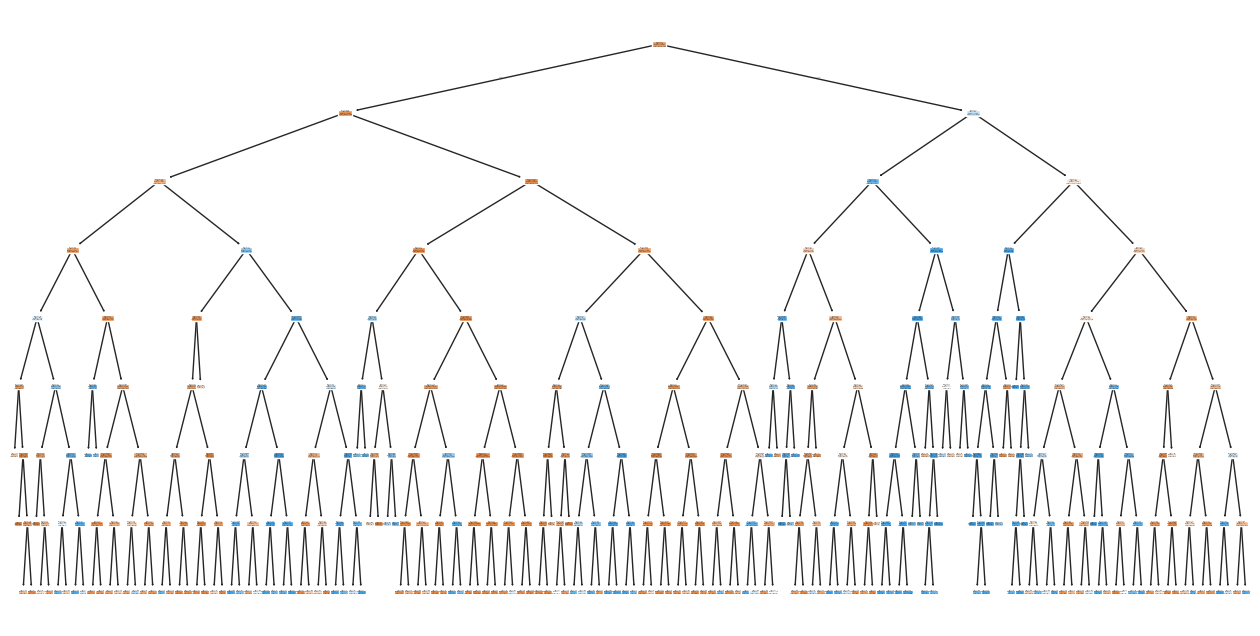

In [31]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))
tree.plot_tree(tree_clf, filled=True)
plt.show()

In [32]:
%%time

cv_scores = cross_val_score(tree_clf, X, y, cv=5)
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Average CV Score: {cv_scores.mean()}")

Cross-Validation Scores: [0.93730809 0.94122665 0.94404163 0.94694191 0.94267679]
Average CV Score: 0.942439012060292
CPU times: total: 266 ms
Wall time: 263 ms


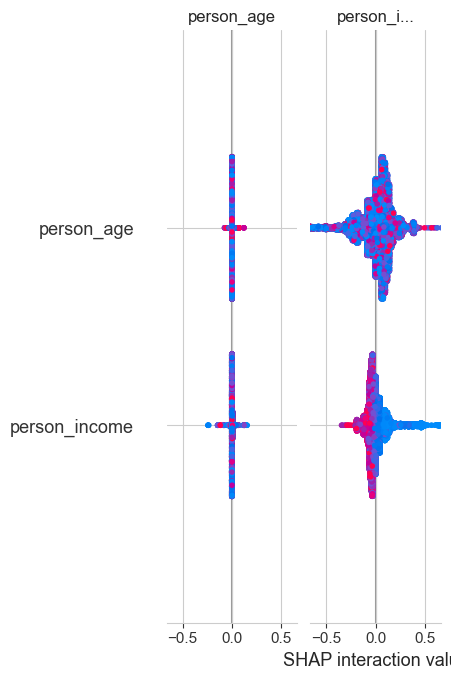

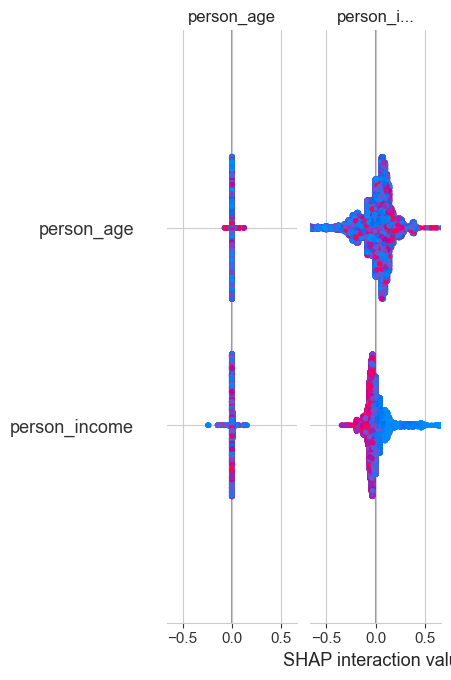

CPU times: total: 2.2 s
Wall time: 2.38 s


In [33]:
%%time
import matplotlib.pyplot as plt 
import shap
shap.initjs()

shap_values = shap.Explainer(tree_clf).shap_values(X_train.values)

shap.summary_plot(shap_values, X_train)
shap.summary_plot(shap_values, X_train, plot_type="bar",show=False)
#plt.gcf().set_size_inches(20, 10)
plt.show()

### Random Forest

In [34]:
from sklearn.ensemble import RandomForestClassifier

n_estimators_range = [1, 5, 10, 20, 50, 80, 100]
max_leaf_nodes_range = [ 2, 5, 8, 10, 12, 15, 20, 25, 30]
max_depth_range = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15]

# Initialize variables to track the best combination and accuracy
best_rf_accuracy = 0
best_rf_params = (None, None, None)
# Triple for loop to iterate over all combinations of hyperparameters
for n_estimators in n_estimators_range:
    for max_leaf_nodes in max_leaf_nodes_range:
        for max_depth in max_depth_range: 
            # Create a new Random Forest classifier with the current hyperparameters
            rf_classifier = RandomForestClassifier(n_estimators=n_estimators, 
                                                   max_leaf_nodes=max_leaf_nodes, 
                                                   max_depth=max_depth, 
                                                   random_state=42)           
            # Train the model on the training split data
            rf_classifier.fit(X_train_split, y_train_split)           
            # Predict on the validation set
            y_val_pred_rf = rf_classifier.predict(X_val)            
            # Calculate the validation accuracy
            val_accuracy = accuracy_score(y_val, y_val_pred_rf)           
            # If this combination gives better accuracy, update the best parameters
            if val_accuracy > best_rf_accuracy:
                best_rf_accuracy = val_accuracy
                best_rf_params = (n_estimators, max_leaf_nodes, max_depth)

# Display the best parameters and their associated accuracy
print(f"Best Random Forest Parameters: n_estimators={best_rf_params[0]}, max_leaf_nodes={best_rf_params[1]}, max_depth={best_rf_params[2]}")
print(f"Best Validation Accuracy: {best_rf_accuracy}")

Best Random Forest Parameters: n_estimators=80, max_leaf_nodes=30, max_depth=12
Best Validation Accuracy: 0.9270135250396003


In [35]:
start_time = time.time()
rf_classifier = RandomForestClassifier(n_estimators=80, max_leaf_nodes=30, max_depth=12, random_state=42)           
rf_classifier.fit(X_train, y_train)
y_pred = rf_classifier.predict(X_test)
time_RF = time.time()-start_time
print("--- %s seconds ---" % time_DT)

score_RF = rf_classifier.score(X_train, y_train)
print('Accuracy train data: %.2f%%' % (score_RF * 100))
accuracy_RF = accuracy_score(y_test, y_pred)
precision_RF = precision_score(y_test, y_pred)
recall_RF = recall_score(y_test, y_pred)
fscore_RF = f1_score(y_test, y_pred)
print('Accuracy predict: %.2f%%' % (accuracy_RF * 100.0))
print('Precision: %.2f%%' % (precision_RF * 100.0))
print('Recall: %.2f%%' % (recall_RF * 100.0))
print('F1_score: %.2f%%' % (fscore_RF * 100.0))
for i, tree in enumerate(rf_classifier.estimators_):
    root_node_impurity = tree.tree_.impurity[0]
    print(f"Tree {i+1} Root Node Gini Impurity: {root_node_impurity}")

--- 0.0465395450592041 seconds ---
Accuracy train data: 92.67%
Accuracy predict: 93.09%
Precision: 91.58%
Recall: 56.15%
F1_score: 69.62%
Tree 1 Root Node Gini Impurity: 0.24720555260009192
Tree 2 Root Node Gini Impurity: 0.24567825447966096
Tree 3 Root Node Gini Impurity: 0.2513475318435904
Tree 4 Root Node Gini Impurity: 0.24120905103531842
Tree 5 Root Node Gini Impurity: 0.24299441444428926
Tree 6 Root Node Gini Impurity: 0.2434834331501209
Tree 7 Root Node Gini Impurity: 0.24057744731350517
Tree 8 Root Node Gini Impurity: 0.23959342252864557
Tree 9 Root Node Gini Impurity: 0.243657969830685
Tree 10 Root Node Gini Impurity: 0.2468935249226467
Tree 11 Root Node Gini Impurity: 0.2500051413894391
Tree 12 Root Node Gini Impurity: 0.24699755553193747
Tree 13 Root Node Gini Impurity: 0.24390222139392137
Tree 14 Root Node Gini Impurity: 0.2482096659724028
Tree 15 Root Node Gini Impurity: 0.24536528592928497
Tree 16 Root Node Gini Impurity: 0.24176983030966448
Tree 17 Root Node Gini Impurit

AUC = 0.91


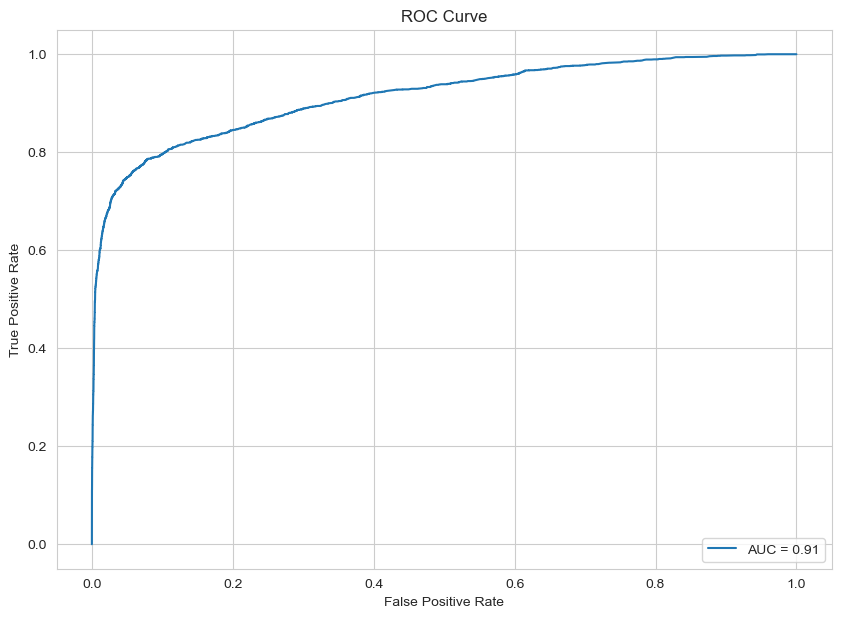

In [36]:
# Compute the ROC curve
y_pred_proba = rf_classifier.predict_proba(X_test)[:,1]  
fpr_RF, tpr_RF, _ = metrics.roc_curve(y_test, y_pred_proba)
auc_RF = metrics.roc_auc_score(y_test, y_pred_proba)
print("AUC = {:.2f}".format(auc_RF))

plt.figure(figsize=(10,7))
plt.plot(fpr_RF, tpr_RF, label="AUC = {:.2f}".format(auc_RF))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc=4)
plt.grid(True)
plt.show()

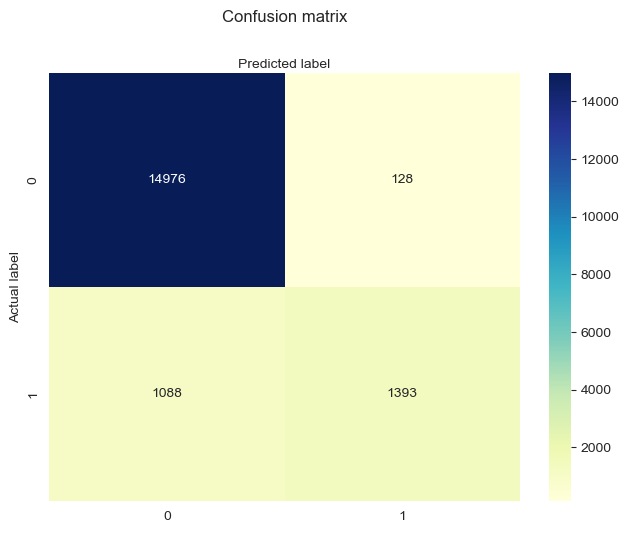

In [37]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

class_names = [0, 1]  
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)


sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
 

plt.show()

In [38]:
%%time

cv_scores = cross_val_score(rf_classifier, X, y, cv=5)
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Average CV Score: {cv_scores.mean()}")

Cross-Validation Scores: [0.92621972 0.92706645 0.92766357 0.92723706 0.92817538]
Average CV Score: 0.9272724350469976
CPU times: total: 4.45 s
Wall time: 4.55 s


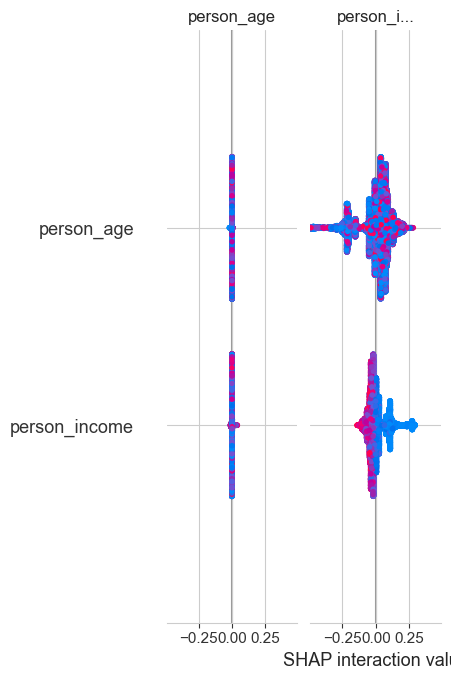

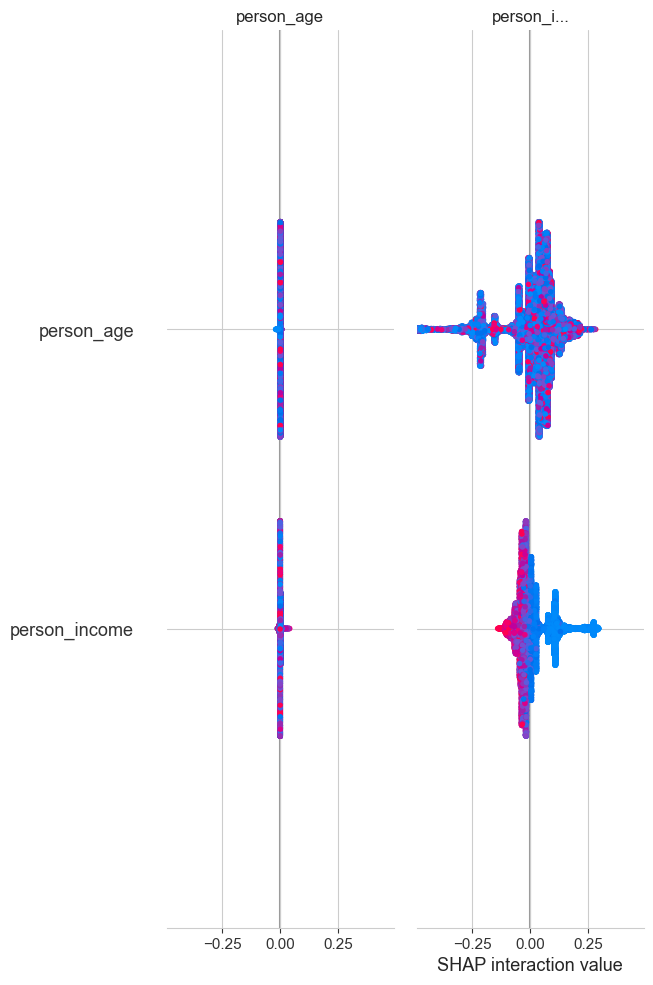

CPU times: total: 9.12 s
Wall time: 9.42 s


In [39]:
%%time

shap_values = shap.Explainer(rf_classifier).shap_values(X_train.values)

shap.summary_plot(shap_values, X_train)
shap.summary_plot(shap_values, X_train, plot_type="bar",show=False)
plt.gcf().set_size_inches(20, 10)
plt.show()

### Gradient Boosted Decision Tree (GBDT)

In [40]:
from sklearn.ensemble import GradientBoostingClassifier

n_estimators_range = [1, 5, 10, 20, 50, 80, 100]
learning_rate_range = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1]
max_depth_range = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15]

# Initialize variables to track the best combination and accuracy
best_gbdt_accuracy = 0
best_gbdt_params = (None, None, None)
# Triple for loop to iterate over all combinations of hyperparameters
for n_estimators in n_estimators_range:
    for learning_rate in learning_rate_range:
        for max_depth in max_depth_range:
            # Create a new Random Forest classifier with the current hyperparameters
            gbdt_clf = GradientBoostingClassifier(n_estimators=n_estimators,
                                                   learning_rate=learning_rate,
                                                   max_depth=max_depth,
                                                   random_state=42)
            # Train the model on the training split data
            gbdt_clf.fit(X_train_split, y_train_split)      
            # Predict on the validation set
            y_val_pred_gbdt = gbdt_clf.predict(X_val)
            # Calculate the validation accuracy
            val_accuracy = accuracy_score(y_val, y_val_pred_gbdt)
            # If this combination gives better accuracy, update the best parameters
            if val_accuracy > best_gbdt_accuracy:
                best_gbdt_accuracy = val_accuracy
                best_gbdt_params = (n_estimators, learning_rate, max_depth)

# Display the best parameters and their associated accuracy
print(f"Best Gradient Boosted Decision Tree Parameters: n_estimators={best_gbdt_params[0]}, learning_rate={best_gbdt_params[1]}, max_depth={best_gbdt_params[2]}")
print(f"Best Validation Accuracy: {best_gbdt_accuracy}")

'n_estimators_range = [1, 5, 10, 20, 50, 80, 100]\nlearning_rate_range = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1]\nmax_depth_range = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15]\n\n# Initialize variables to track the best combination and accuracy\nbest_gbdt_accuracy = 0\nbest_gbdt_params = (None, None, None)\n# Triple for loop to iterate over all combinations of hyperparameters\nfor n_estimators in n_estimators_range:\n    for learning_rate in learning_rate_range:\n        for max_depth in max_depth_range:\n            # Create a new Random Forest classifier with the current hyperparameters\n            gbdt_clf = GradientBoostingClassifier(n_estimators=n_estimators,\n                                                   learning_rate=learning_rate,\n                                                   max_depth=max_depth,\n                                                   random_state=42)\n            # Train the model on the training split data\n            gbdt_clf.fit(X_train

In [41]:
start_time = time.time()
gbdt_clf = GradientBoostingClassifier(n_estimators=100 ,learning_rate= 0.1, max_depth= 6, random_state=42)           
gbdt_clf.fit(X_train, y_train)
y_pred = gbdt_clf.predict(X_test)
time_GBDT = time.time()-start_time
print("--- %s seconds ---" % time_GBDT)

score_GBDT = gbdt_clf.score(X_train, y_train)
print('Accuracy train data: %.2f%%' % (score_GBDT * 100))
accuracy_GBDT = accuracy_score(y_test, y_pred)
precision_GBDT = precision_score(y_test, y_pred)
recall_GBDT = recall_score(y_test, y_pred)
fscore_GBDT = f1_score(y_test, y_pred)
print('Accuracy predict: %.2f%%' % (accuracy_GBDT * 100.0))
print('Precision: %.2f%%' % (precision_GBDT * 100.0))
print('Recall: %.2f%%' % (recall_GBDT * 100.0))
print('F1_score: %.2f%%' % (fscore_GBDT * 100.0))

--- 3.9420993328094482 seconds ---
Accuracy train data: 95.82%
Accuracy predict: 95.08%
Precision: 90.72%
Recall: 72.51%
F1_score: 80.60%


AUC = 0.96


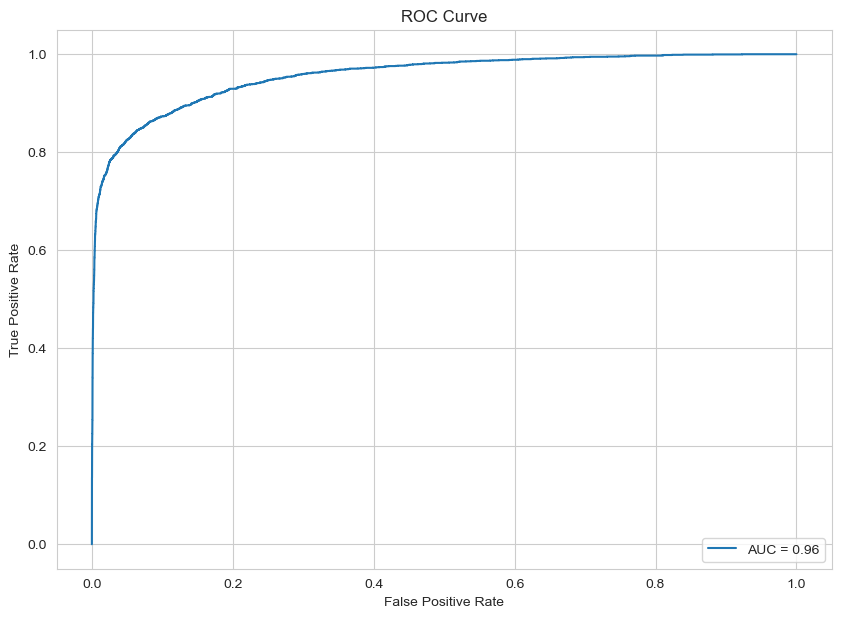

In [42]:
# Compute the ROC curve
y_pred_proba = gbdt_clf.predict_proba(X_test)[:,1]  
fpr_GBDT, tpr_GBDT, _ = metrics.roc_curve(y_test, y_pred_proba)
auc_GBDT = metrics.roc_auc_score(y_test, y_pred_proba)
print("AUC = {:.2f}".format(auc_GBDT))

plt.figure(figsize=(10,7))
plt.plot(fpr_GBDT, tpr_GBDT, label="AUC = {:.2f}".format(auc_GBDT))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc=4)
plt.grid(True)
plt.show()

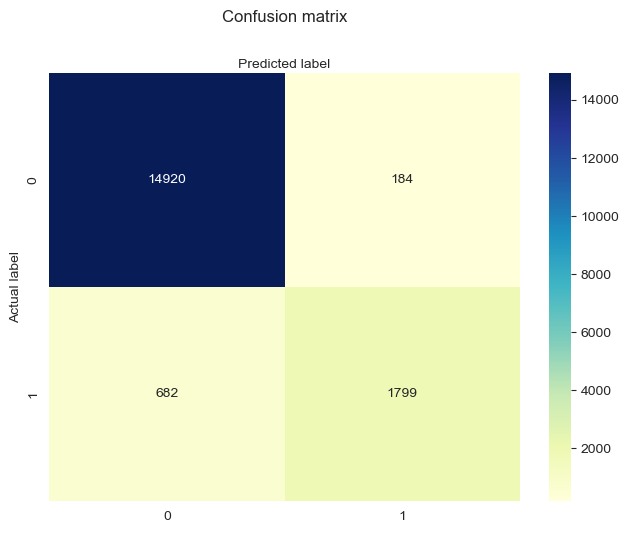

In [43]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

class_names = [0, 1]  
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)


sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
 

plt.show()

In [44]:
%%time

cv_scores = cross_val_score(gbdt_clf, X, y, cv=5)
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Average CV Score: {cv_scores.mean()}")

Cross-Validation Scores: [0.9476288  0.9500128  0.94856265 0.9538514  0.94941568]
Average CV Score: 0.9498942654816066
CPU times: total: 21.8 s
Wall time: 22.3 s


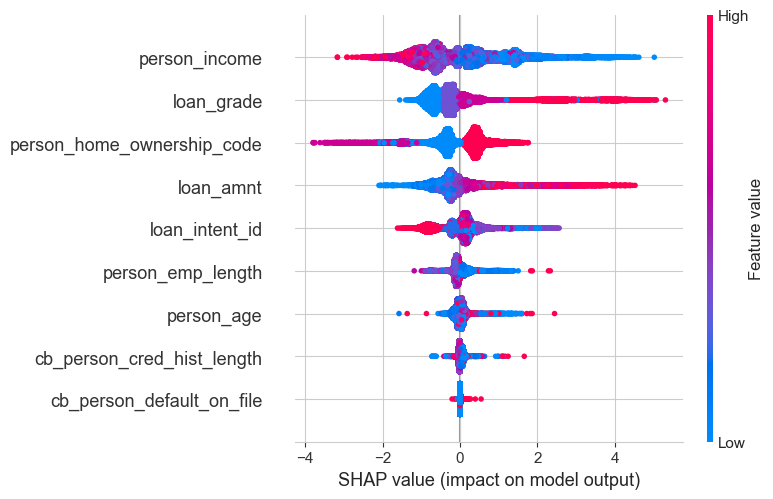

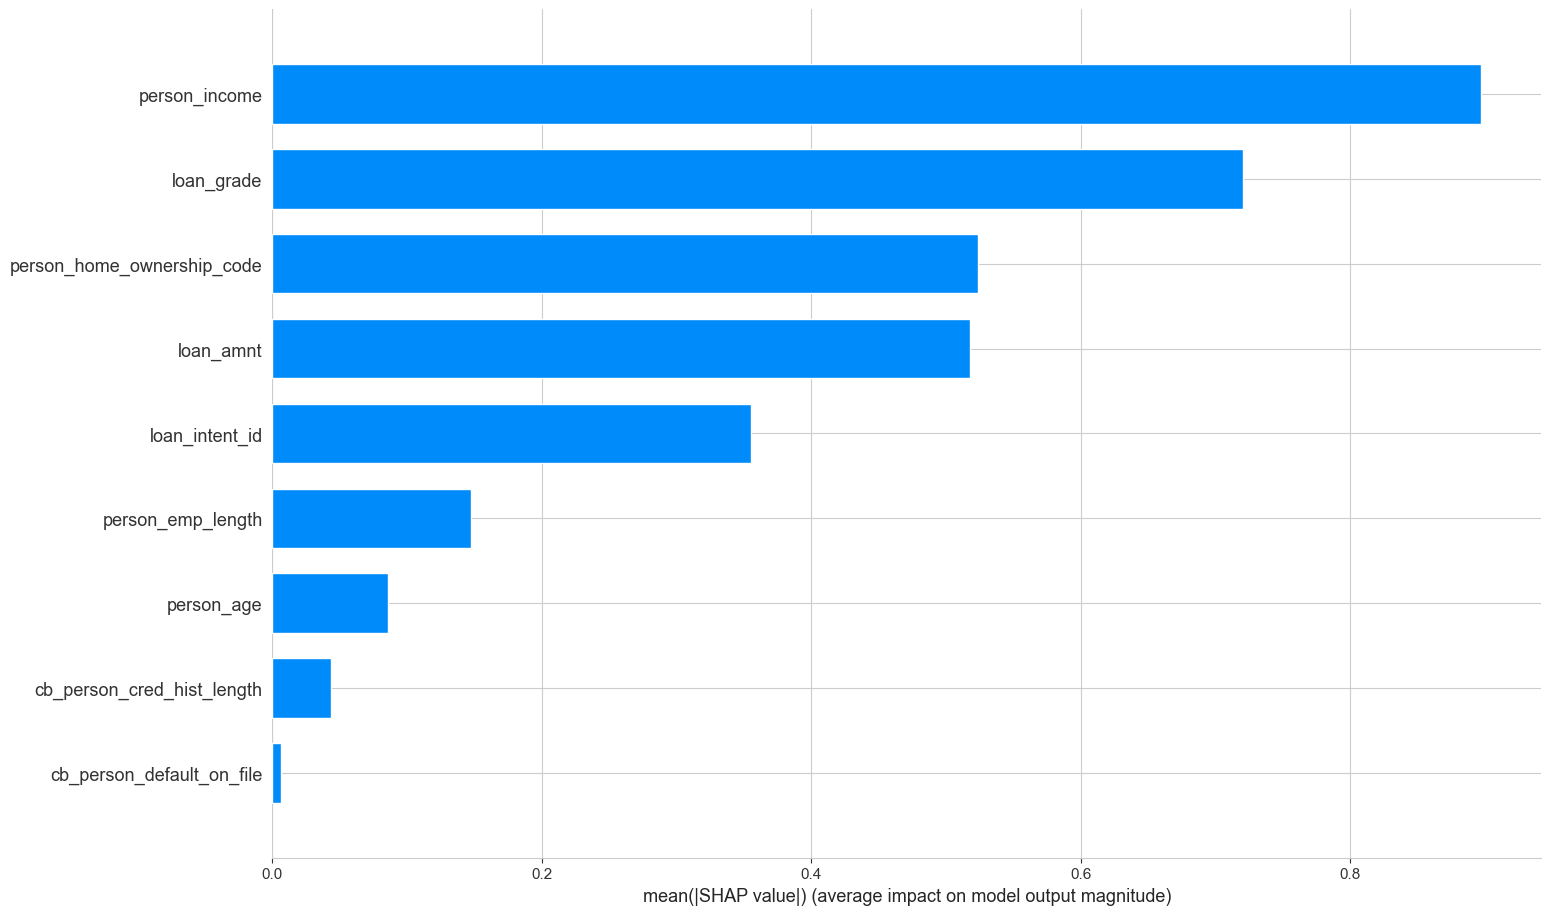

CPU times: total: 17.1 s
Wall time: 17.3 s


In [45]:
%%time

shap_values = shap.Explainer(gbdt_clf).shap_values(X_train.values)

shap.summary_plot(shap_values, X_train)
shap.summary_plot(shap_values, X_train, plot_type="bar",show=False)
plt.gcf().set_size_inches(20, 10)
plt.show()

### XGBoost

In [46]:
from xgboost import XGBClassifier

n_estimators_range = [1, 5, 10, 20, 50, 80, 100]
learning_rate_range = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1]
max_depth_range = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15]

# Initialize variables to track the best combination and accuracy
best_xgb_accuracy = 0
best_xgb_params = (None, None, None)

# Triple for loop to iterate over all combinations of hyperparameters
for n_estimators in n_estimators_range:
    for learning_rate in learning_rate_range:
        for max_depth in max_depth_range:
            # Create a new XGBClassifier with the current hyperparameters
            model_xgb = XGBClassifier(n_estimators=n_estimators,
                                  learning_rate=learning_rate,
                                  max_depth=max_depth,
                                  random_state=0,
                                  use_label_encoder=False,  # Add this if you encounter warnings
                                  eval_metric='logloss')  # Required to suppress warnings in newer versions
            # Train the model on the training split data
            model_xgb.fit(X_train_split, y_train_split)
            # Predict on the validation set
            y_val_pred_xgb = model_xgb.predict(X_val)
            # Calculate the validation accuracy
            val_accuracy = accuracy_score(y_val, y_val_pred_xgb)
            # If this combination gives better accuracy, update the best parameters
            if val_accuracy > best_xgb_accuracy:
                best_xgb_accuracy = val_accuracy
                best_xgb_params = (n_estimators, learning_rate, max_depth)

# Display the best parameters and their associated accuracy
print(f"Best XGBoost Parameters: n_estimators={best_xgb_params[0]}, learning_rate={best_xgb_params[1]}, max_depth={best_xgb_params[2]}")
print(f"Best Validation Accuracy: {best_xgb_accuracy:.4f}")

'n_estimators_range = [1, 5, 10, 20, 50, 80, 100]\nlearning_rate_range = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1]\nmax_depth_range = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15]\n\n# Initialize variables to track the best combination and accuracy\nbest_xgb_accuracy = 0\nbest_xgb_params = (None, None, None)\n\n# Triple for loop to iterate over all combinations of hyperparameters\nfor n_estimators in n_estimators_range:\n    for learning_rate in learning_rate_range:\n        for max_depth in max_depth_range:\n            # Create a new XGBClassifier with the current hyperparameters\n            model_xgb = XGBClassifier(n_estimators=n_estimators,\n                                  learning_rate=learning_rate,\n                                  max_depth=max_depth,\n                                  random_state=0,\n                                  use_label_encoder=False,  # Add this if you encounter warnings\n                                  eval_metric=\'logloss\')  # Required to suppress 

In [47]:
start_time = time.time()
xgb = XGBClassifier(booster='gbtree', n_estimators=80, learning_rate=0.1, max_depth=9, random_state=0,
                    use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
time_XGB = time.time()-start_time
print("--- %s seconds ---" % time_XGB)

score_XGB = xgb.score(X_train, y_train)
print('Accuracy train data: %.2f%%' % (score_XGB * 100))
accuracy_XGB = accuracy_score(y_test, y_pred)
precision_XGB = precision_score(y_test, y_pred)
recall_XGB = recall_score(y_test, y_pred)
fscore_XGB = f1_score(y_test, y_pred)
print('Accuracy predict: %.2f%%' % (accuracy_XGB * 100.0))
print('Precision: %.2f%%' % (precision_XGB * 100.0))
print('Recall: %.2f%%' % (recall_XGB * 100.0))
print('F1_score: %.2f%%' % (fscore_XGB * 100.0))

--- 0.3143444061279297 seconds ---
Accuracy train data: 96.31%
Accuracy predict: 95.00%
Precision: 90.45%
Recall: 72.19%
F1_score: 80.30%


AUC = 0.95


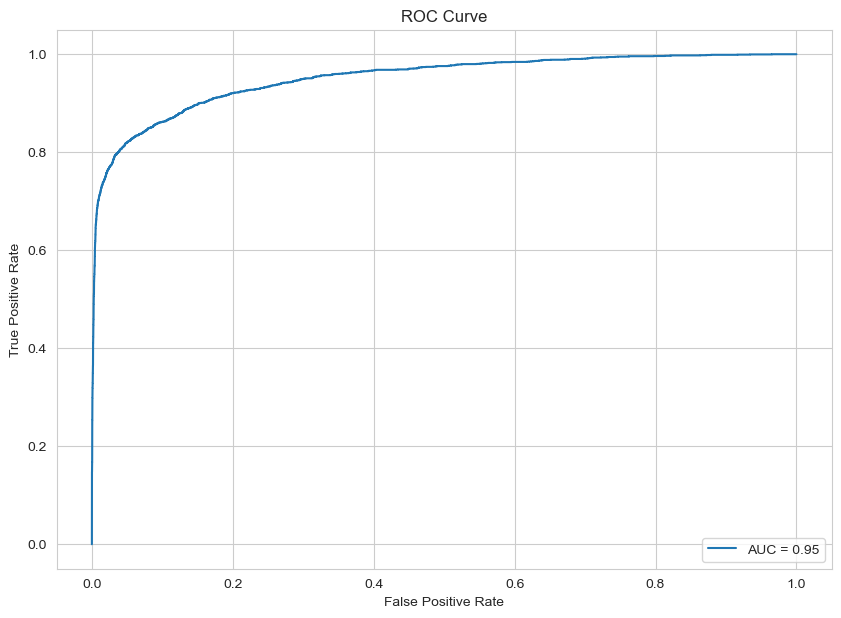

In [48]:
# Compute the ROC curve
y_pred_proba = xgb.predict_proba(X_test)[:,1]  
fpr_XGB, tpr_XGB, _ = metrics.roc_curve(y_test, y_pred_proba)
auc_XGB = metrics.roc_auc_score(y_test, y_pred_proba)
print("AUC = {:.2f}".format(auc_XGB))

plt.figure(figsize=(10,7))
plt.plot(fpr_XGB, tpr_XGB, label="AUC = {:.2f}".format(auc_XGB))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc=4)
plt.grid(True)
plt.show()

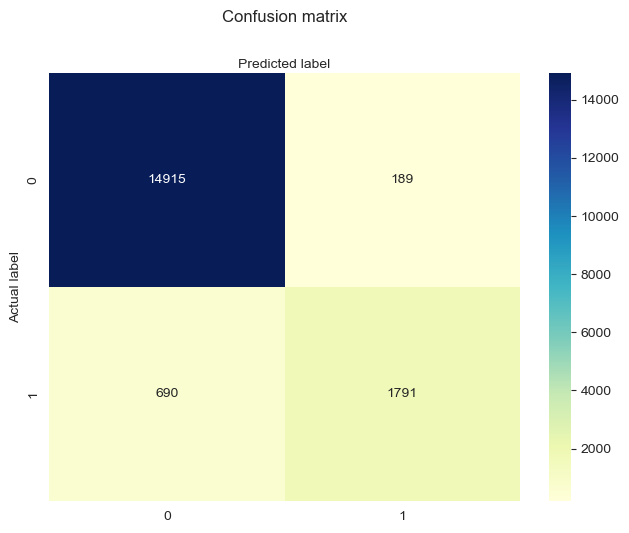

In [49]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

class_names = [0, 1]  
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)


sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
 

plt.show()

In [50]:
%%time

cv_scores = cross_val_score(xgb, X, y, cv=5)
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Average CV Score: {cv_scores.mean()}")

Cross-Validation Scores: [0.94831116 0.9500981  0.94907447 0.95351019 0.9500981 ]
Average CV Score: 0.9502184029487912
CPU times: total: 12.6 s
Wall time: 758 ms


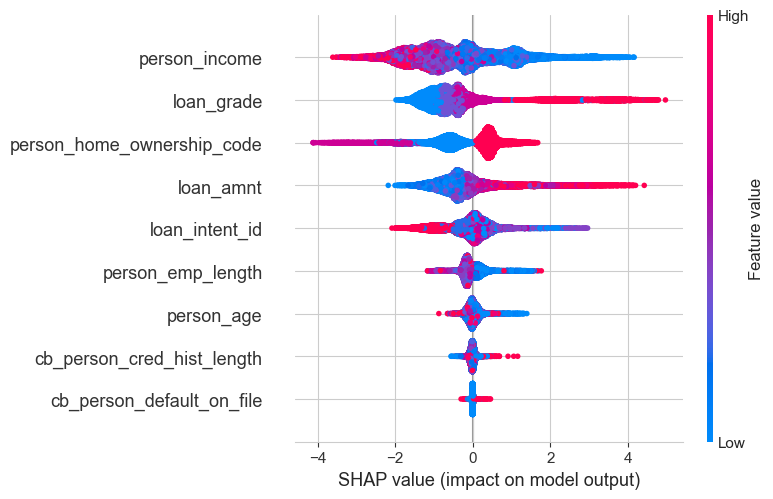

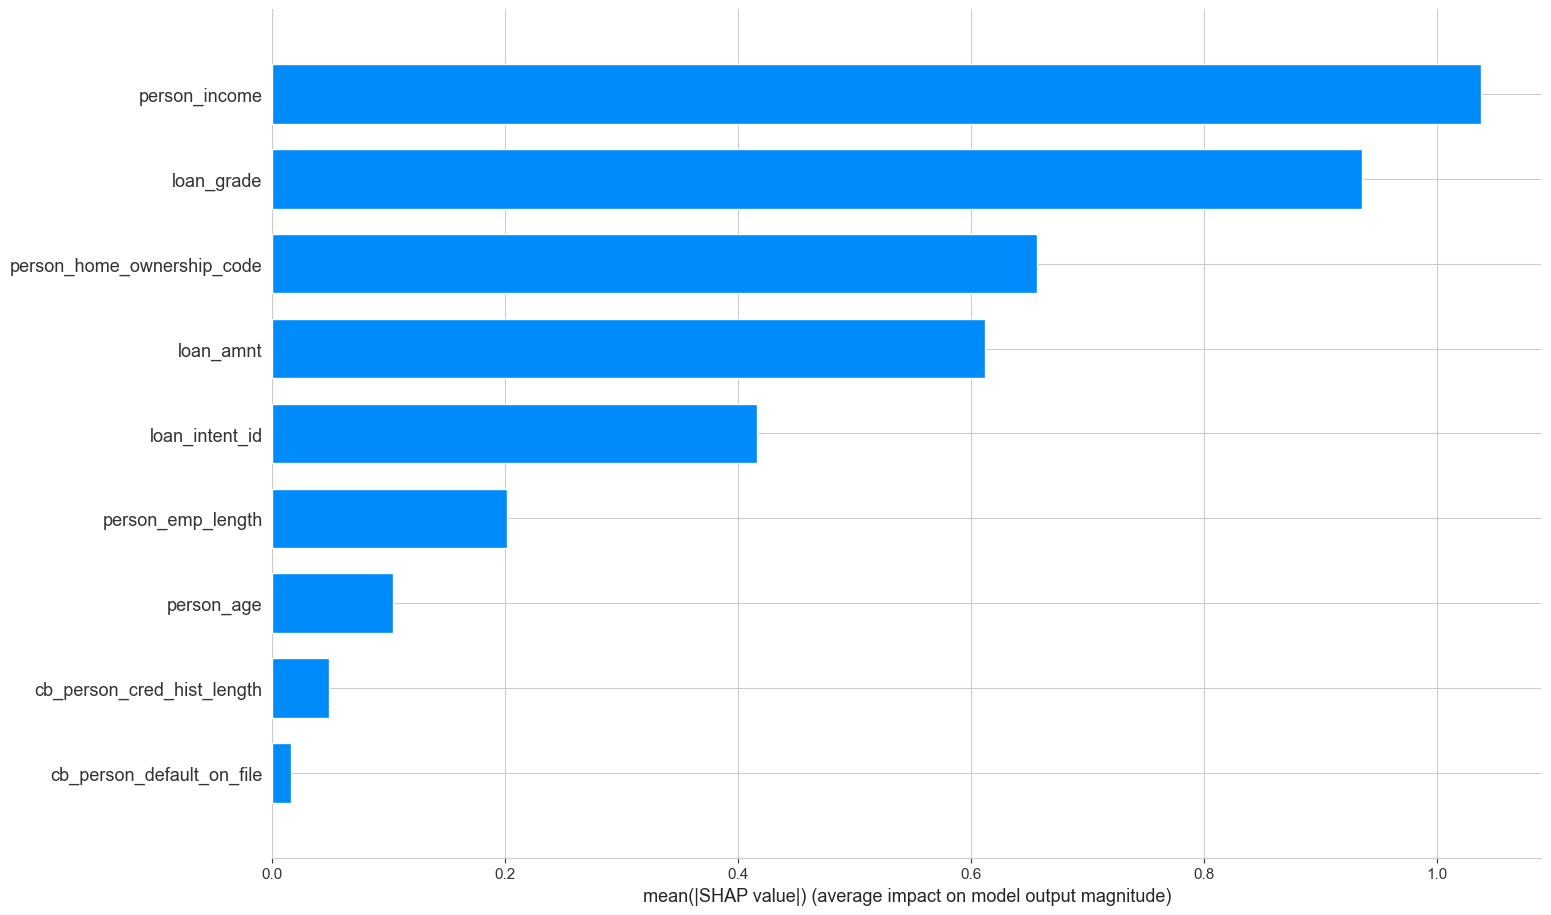

CPU times: total: 1min 54s
Wall time: 8.13 s


In [51]:
%%time

shap_values = shap.Explainer(xgb).shap_values(X_train.values)

shap.summary_plot(shap_values, X_train)
shap.summary_plot(shap_values, X_train, plot_type="bar",show=False)
plt.gcf().set_size_inches(20, 10)
plt.show()

### LightGB

In [52]:
import lightgbm as lgb

n_estimators_range = [1, 5, 10, 20, 50, 80, 100]
learning_rate_range = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1]
max_depth_range = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15]

# Initialize variables to track the best combination and accuracy
best_lgb_accuracy = 0
best_lgb_params = (None, None, None)
# Triple for loop to iterate over all combinations of hyperparameters
for n_estimators in n_estimators_range:
    for learning_rate in learning_rate_range:
        for max_depth in max_depth_range:
            # Create a new Random Forest classifier with the current hyperparameters
            lgb_clf = lgb.LGBMClassifier(n_estimators=n_estimators,
                                                   learning_rate=learning_rate,
                                                   max_depth=max_depth,
                                                   random_state=42, verbose=-1)
            # Train the model on the training split data
            lgb_clf.fit(X_train_split, y_train_split)      
            # Predict on the validation set
            y_val_pred_lgb = lgb_clf.predict(X_val)
            # Calculate the validation accuracy
            val_accuracy = accuracy_score(y_val, y_val_pred_lgb)
            # If this combination gives better accuracy, update the best parameters
            if val_accuracy > best_lgb_accuracy:
                best_lgb_accuracy = val_accuracy
                best_lgb_params = (n_estimators, learning_rate, max_depth)

# Display the best parameters and their associated accuracy
print(f"Best LightGBM Parameters: n_estimators={best_lgb_params[0]}, learning_rate={best_lgb_params[1]}, max_depth={best_lgb_params[2]}")
print(f"Best Validation Accuracy: {best_lgb_accuracy}")

'n_estimators_range = [1, 5, 10, 20, 50, 80, 100]\nlearning_rate_range = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1]\nmax_depth_range = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15]\n\n# Initialize variables to track the best combination and accuracy\nbest_lgb_accuracy = 0\nbest_lgb_params = (None, None, None)\n# Triple for loop to iterate over all combinations of hyperparameters\nfor n_estimators in n_estimators_range:\n    for learning_rate in learning_rate_range:\n        for max_depth in max_depth_range:\n            # Create a new Random Forest classifier with the current hyperparameters\n            lgb_clf = lgb.LGBMClassifier(n_estimators=n_estimators,\n                                                   learning_rate=learning_rate,\n                                                   max_depth=max_depth,\n                                                   random_state=42, verbose=-1)\n            # Train the model on the training split data\n            lgb_clf.fit(X_train

In [53]:
start_time = time.time()
lgb_clf = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.5, 
                             max_depth=3, random_state=42,verbose=-1)
lgb_clf.fit(X_train, y_train)
y_pred = lgb_clf.predict(X_test)
time_lgb = time.time()-start_time
print("--- %s seconds ---" % time_lgb)

score_lgb = lgb_clf.score(X_train, y_train)
print('Accuracy train data: %.2f%%' % (score_lgb * 100))
accuracy_lgb = accuracy_score(y_test, y_pred)
precision_lgb = precision_score(y_test, y_pred)
recall_lgb = recall_score(y_test, y_pred)
fscore_lgb = f1_score(y_test, y_pred)
print('Accuracy predict: %.2f%%' % (accuracy_lgb * 100.0))
print('Precision: %.2f%%' % (precision_lgb * 100.0))
print('Recall: %.2f%%' % (recall_lgb * 100.0))
print('F1_score: %.2f%%' % (fscore_lgb * 100.0))

--- 0.08526945114135742 seconds ---
Accuracy train data: 95.07%
Accuracy predict: 94.72%
Precision: 88.72%
Recall: 71.66%
F1_score: 79.29%


  File "C:\Users\jamestttbc\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\jamestttbc\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jamestttbc\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\jamestttbc\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


AUC = 0.95


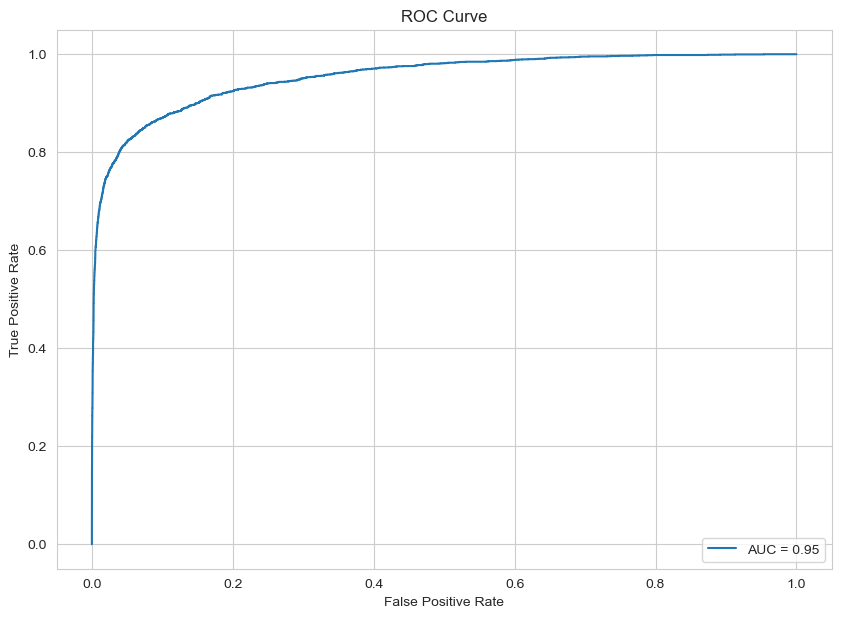

In [54]:
# Compute the ROC curve
y_pred_proba = lgb_clf.predict_proba(X_test)[:,1]  
fpr_lgb, tpr_lgb, _ = metrics.roc_curve(y_test, y_pred_proba)
auc_lgb = metrics.roc_auc_score(y_test, y_pred_proba)
print("AUC = {:.2f}".format(auc_lgb))

plt.figure(figsize=(10,7))
plt.plot(fpr_lgb, tpr_lgb, label="AUC = {:.2f}".format(auc_lgb))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc=4)
plt.grid(True)
plt.show()

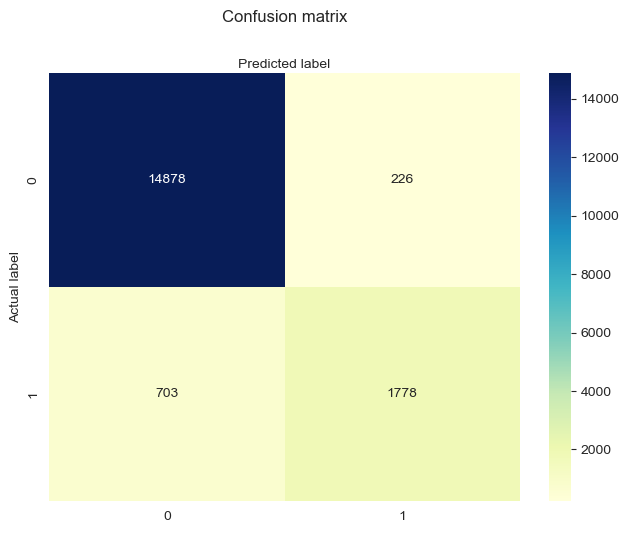

In [55]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

class_names = [0, 1]  
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)


sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
 

plt.show()

In [56]:
%%time

cv_scores = cross_val_score(lgb_clf, X, y, cv=5)
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Average CV Score: {cv_scores.mean()}")

Cross-Validation Scores: [0.94464347 0.94753903 0.9466007  0.95078052 0.95052461]
Average CV Score: 0.9480176636788127
CPU times: total: 6.09 s
Wall time: 424 ms


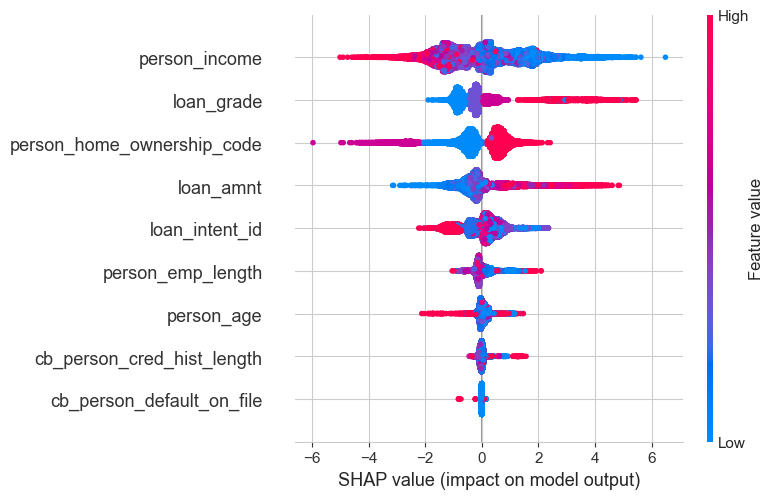

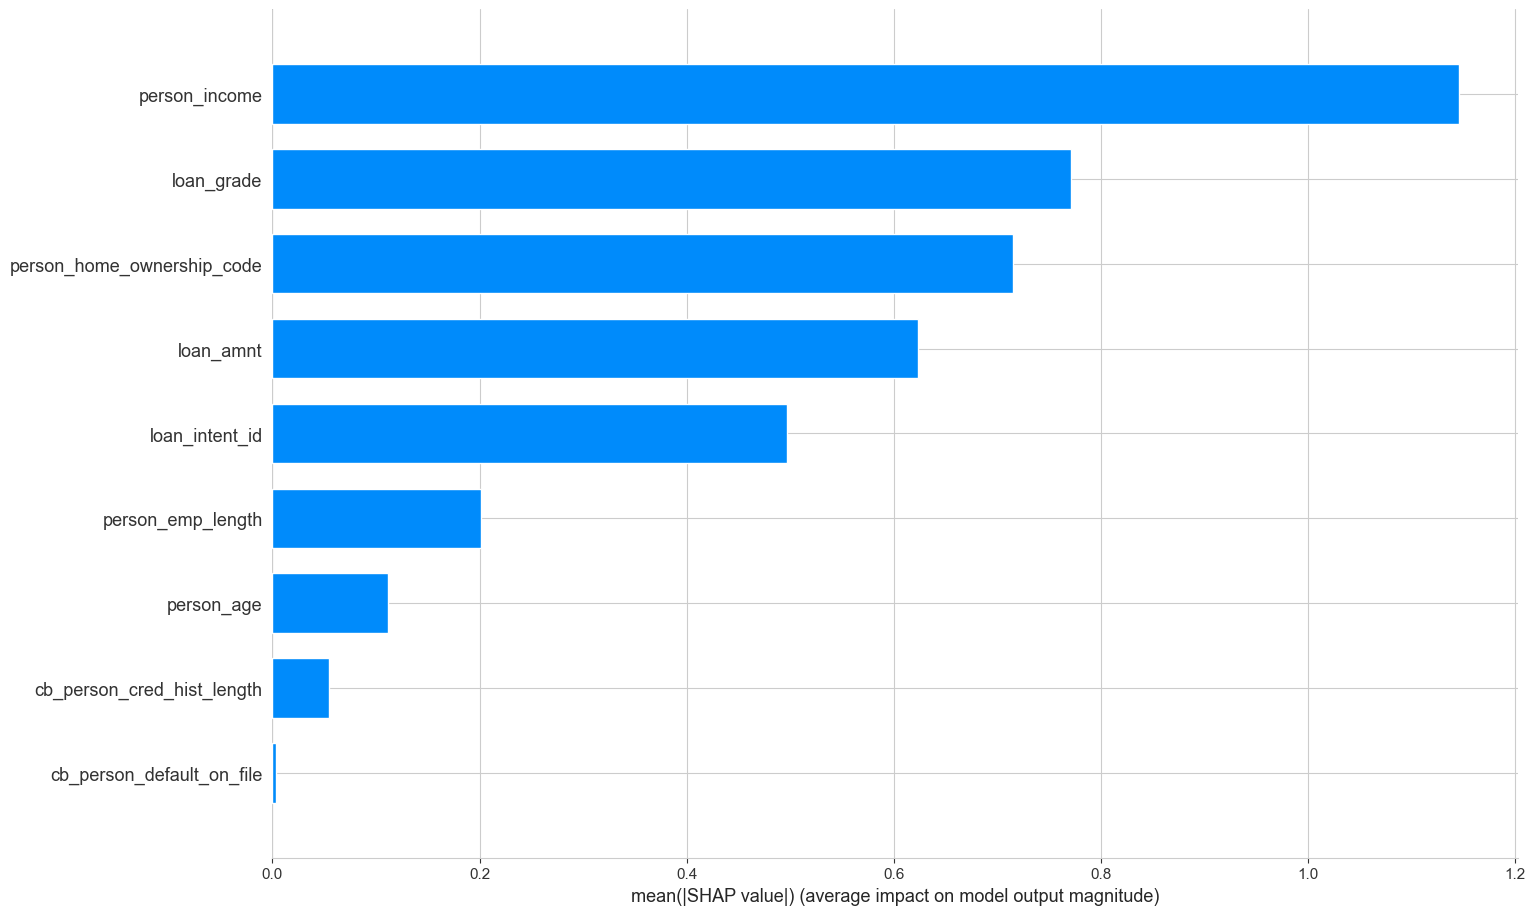

CPU times: total: 5.5 s
Wall time: 1.74 s


In [57]:
%%time

shap_values = shap.Explainer(lgb_clf).shap_values(X_train.values)

shap.summary_plot(shap_values, X_train)
shap.summary_plot(shap_values, X_train, plot_type="bar",show=False)
plt.gcf().set_size_inches(20, 10)
plt.show()

### Dense Neural Network

In [67]:
model = Sequential([
    Dense(128, input_dim=X_train.shape[1], activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(1, activation='sigmoid')  
])

Epoch 1/100
642/642 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6824 - loss: 1.9526 - val_accuracy: 0.8679 - val_loss: 1.3312 - learning_rate: 1.0000e-04
Epoch 2/100
642/642 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8578 - loss: 1.2807 - val_accuracy: 0.8802 - val_loss: 1.0049 - learning_rate: 1.0000e-04
Epoch 3/100
642/642 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8738 - loss: 0.9702 - val_accuracy: 0.8879 - val_loss: 0.7884 - learning_rate: 1.0000e-04
Epoch 4/100
642/642 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8731 - loss: 0.7821 - val_accuracy: 0.8894 - val_loss: 0.6453 - learning_rate: 1.0000e-04
Epoch 5/100
642/642 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8817 - loss: 0.6414 - val_accuracy: 0.8994 - val_loss: 0.5353 - learning_rate: 1.0000e-04
Epoch 6/100
642/642 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8847 - loss: 0.5498 - val_accuracy: 0.9004 - val_loss: 0.4679 - learning_rate: 1.0000e-04
Epoch 7/100
642/642 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - acc

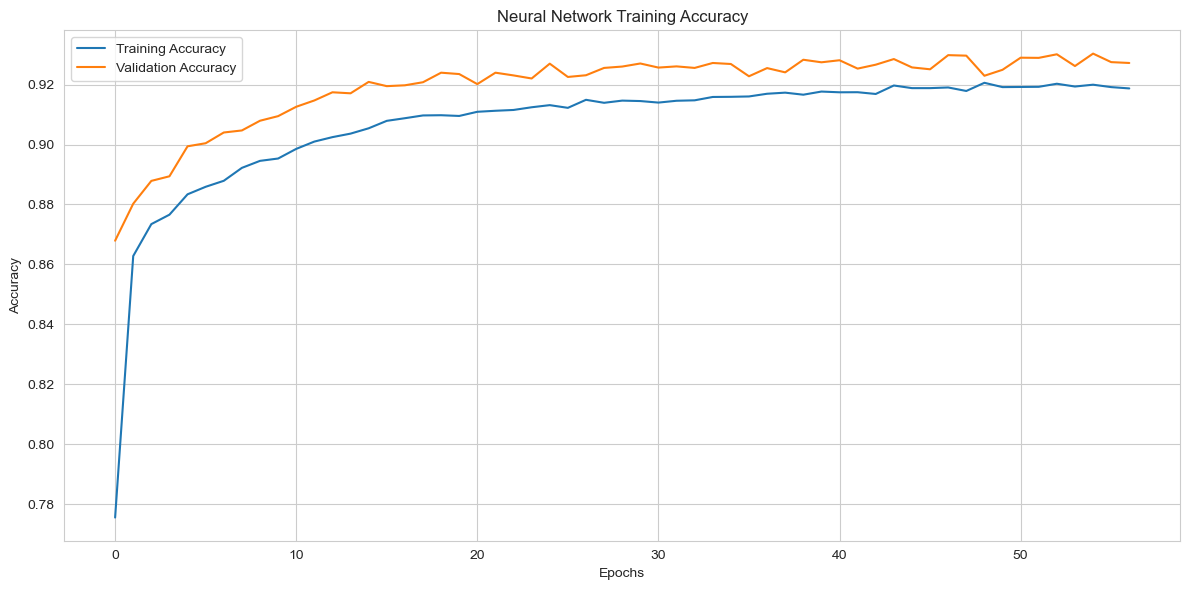

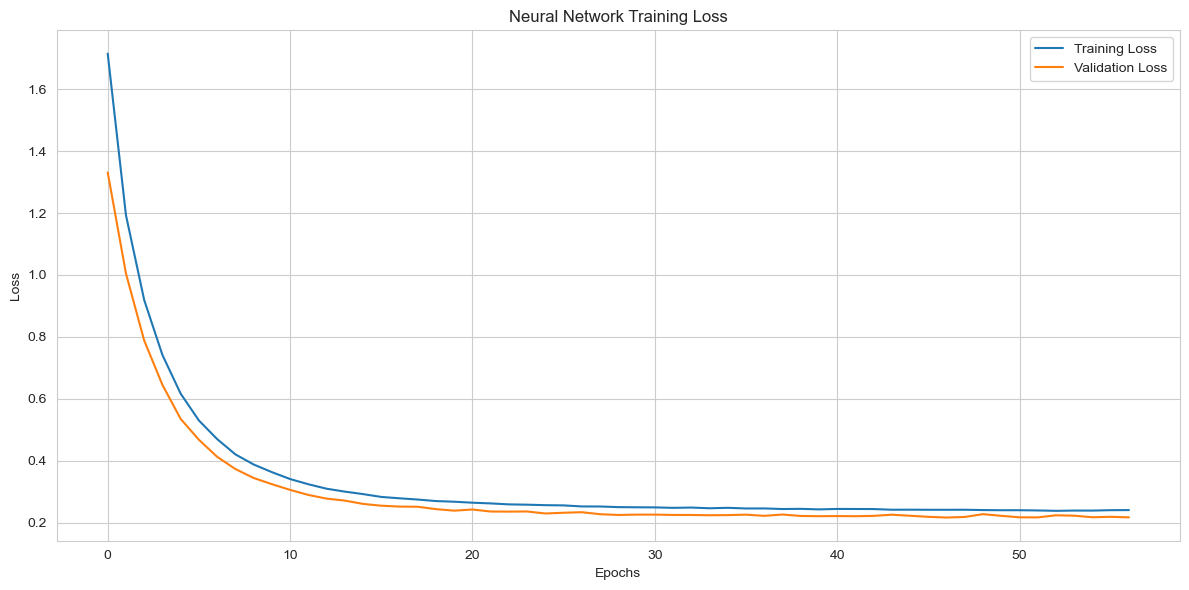

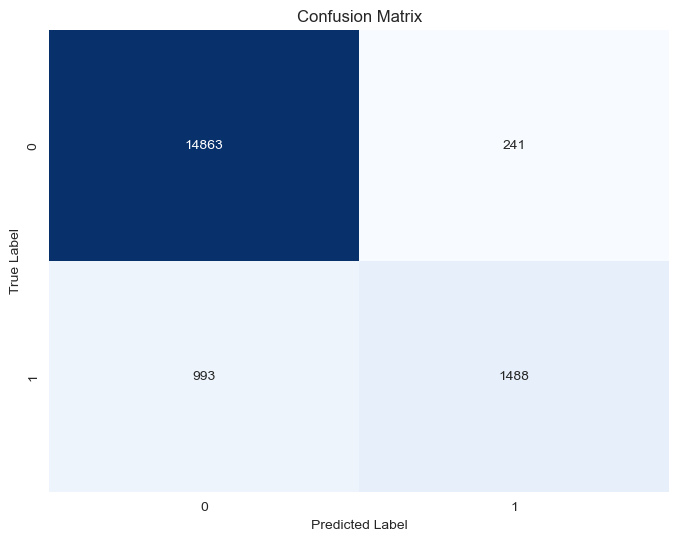

In [68]:
start_time = time.time()
model.compile(optimizer=Adam(learning_rate=0.0001), 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-4)


history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,  # Reduce the number of epochs to avoid overfitting
    batch_size=64,  # Reduce batch size for better generalization
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")


y_pred = (model.predict(X_test) > 0.5).astype(int)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

time_nn = time.time()-start_time
print("---%s seconds ---"% time_nn)

accuracy_nn = accuracy_score(y_test, y_pred)
precision_nn = precision_score(y_test, y_pred)
recall_nn = recall_score(y_test, y_pred)
fscore_nn = f1_score(y_test, y_pred)
print('Accuracy predict: %.2f%%' % (accuracy_nn * 100.0))
print('Precision: %.2f%%' % (precision_nn * 100.0))
print('Recall: %.2f%%' % (recall_nn * 100.0))
print('F1_score: %.2f%%' % (fscore_nn * 100.0))

plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Neural Network Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Neural Network Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## Conclution

In [58]:
dic = {'Model': ['Logisitic Regression', 'Decision Tree', 'Random Forest', 'GBDT','XGBoost','LightGB'], 
            'Runtime': [time_LR, time_DT, time_RF,time_GBDT,time_XGB,time_lgb],
            'Train_Accuracy':[score_LR,score_DT,score_RF,score_GBDT,score_XGB,score_lgb], 
            'Predict_Accuracy':[accuracy_LR,accuracy_DT,accuracy_RF,accuracy_GBDT,accuracy_XGB,accuracy_lgb]}
contrast = pd.DataFrame.from_dict(dic)

In [59]:
contrast

,Model,Runtime,Train_Accuracy,Predict_Accuracy
0,Logisitic Regression,0.196691,0.891204,0.894512
1,Decision Tree,0.046540,0.944554,0.942678
2,Random Forest,0.800598,0.926690,0.930850
3,GBDT,3.942099,0.958202,0.950753
4,XGBoost,0.314344,0.963052,0.950014
5,LightGB,0.085269,0.950720,0.947171


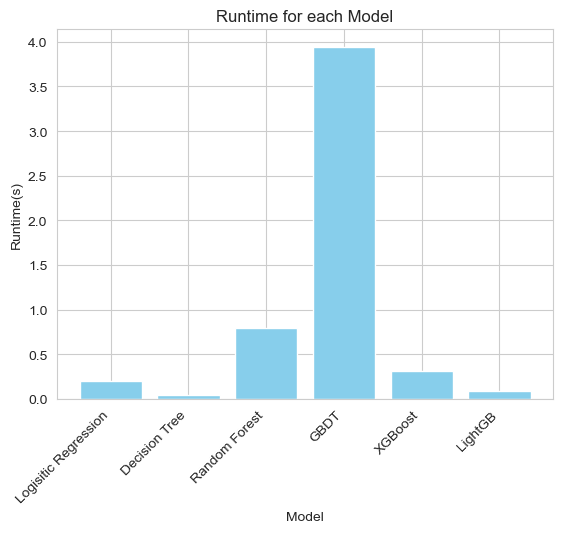

In [60]:
plt.bar(contrast['Model'], contrast['Runtime'], color='skyblue')
plt.title('Runtime for each Model')
plt.xlabel('Model')
plt.ylabel('Runtime(s)')
plt.xticks(rotation=45, ha='right')
plt.show()

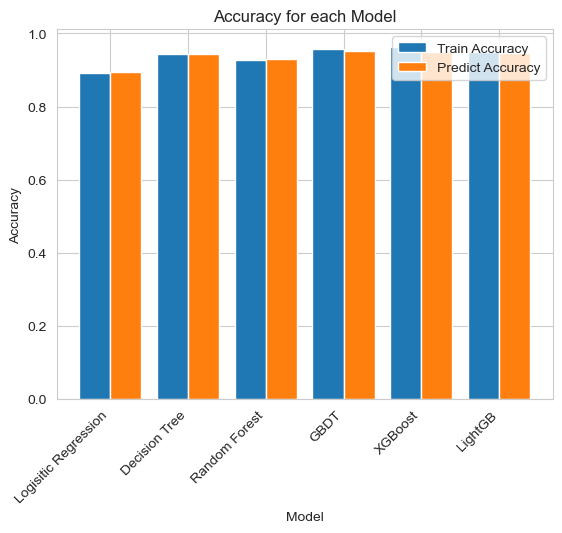

In [61]:
X_axis = np.arange(len(contrast['Model'])) 
  
plt.bar(X_axis - 0.2, contrast['Train_Accuracy'], 0.4, label = 'Train Accuracy') 
plt.bar(X_axis + 0.2, contrast['Predict_Accuracy'], 0.4, label = 'Predict Accuracy') 
  
plt.xticks(X_axis, contrast['Model'],rotation=45, ha='right') 
plt.xlabel("Model") 
plt.ylabel("Accuracy") 
plt.title("Accuracy for each Model") 
plt.legend() 
plt.show() 

550/550 ━━━━━━━━━━━━━━━━━━━━ 0s 410us/step


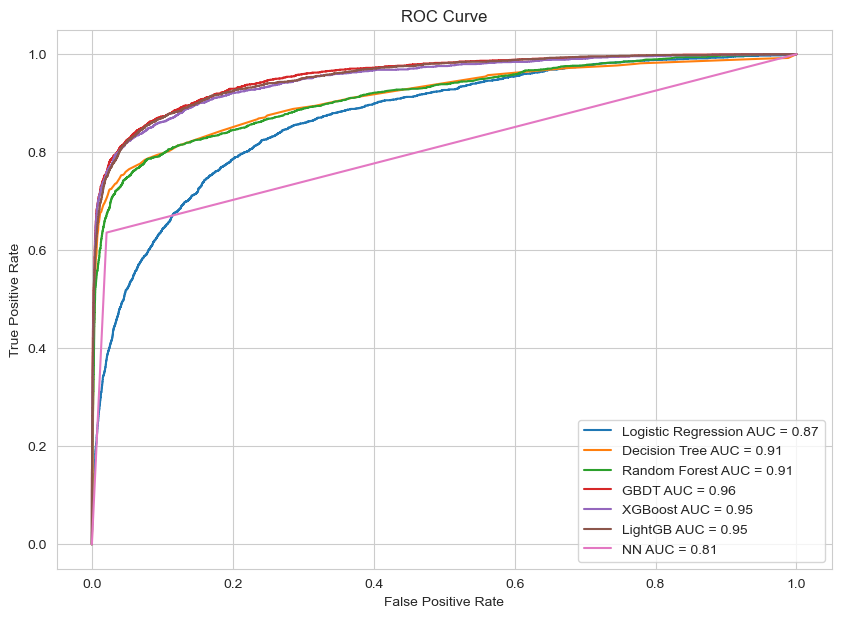

In [65]:
y_pred_proba = (model.predict(X_test) > 0.5).astype(int) 
fpr_NN, tpr_NN, _ = metrics.roc_curve(y_test, y_pred_proba)
auc_NN = metrics.roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(10,7))
plt.plot(fpr_LR, tpr_LR, label="Logistic Regression AUC = {:.2f}".format(auc_LR))
plt.plot(fpr_DT, tpr_DT, label="Decision Tree AUC = {:.2f}".format(auc_DT))
plt.plot(fpr_RF, tpr_RF, label="Random Forest AUC = {:.2f}".format(auc_RF))
plt.plot(fpr_GBDT, tpr_GBDT, label="GBDT AUC = {:.2f}".format(auc_GBDT))
plt.plot(fpr_XGB, tpr_XGB, label="XGBoost AUC = {:.2f}".format(auc_XGB))
plt.plot(fpr_lgb, tpr_lgb, label="LightGB AUC = {:.2f}".format(auc_lgb))
plt.plot(fpr_NN, tpr_NN, label="NN AUC = {:.2f}".format(auc_NN))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc=4)
plt.grid(True)
plt.show()